# Clasificación de Cáncer de Mama — Machine Learning Estadístico
## Aprendizaje Automático Estadístico · MCDA-B Deber Semana 1

**Asignatura:** Aprendizaje automático estadístico MIA-B                
**Docente:** Ivan Danilo Garcia Santillan                       
**Universidad:** UIDE  
**Grupo 1:**
- César Nelson Abarca Araujo
- Nataly Fernanda Lanchimba Caiza
- Jhon Enrique Oña Guamani

**Dataset:** [Breast Cancer Wisconsin (Diagnostic) — UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic)  
**Repositorio GitHub:** [UIDE MIAA-B · Aprendizaje Automático Estadístico · Semana 1 · Tarea G1](https://github.com/cnabarca/Maestria-IA-UIDE/tree/main/5.%20Aprendizaje%20Automatico%20Estadistico/Semana%201/Tarea%20G1)

---

## 1. Descripción del Problema

**Problema:** Clasificación automática de tumores de mama en **Malignos (1)** o **Benignos (0)** a partir de características morfológicas extraídas de imágenes digitales de biopsias de tejido mamario (Fine Needle Aspirate, FNA).

**Justificación del enfoque:**
Cada muestra está descrita por mediciones numéricas del núcleo celular. Se busca aprender un límite de decisión que separe ambas clases con la mayor precisión posible. Los algoritmos seleccionados son:

- **Regresión Logística:** Modelo lineal interpretable; establece la línea base de rendimiento y permite analizar la importancia de cada variable mediante sus coeficientes.
- **K-Nearest Neighbors (K-NN):** Algoritmo no paramétrico basado en distancia; captura fronteras de decisión no lineales sin asumir distribución de los datos.
- **Naive Bayes:** Clasificador probabilístico basado en el Teorema de Bayes; eficiente y robusto cuando las variables tienen cierta independencia condicional.

**Contexto clínico:** Un diagnóstico erróneo tiene consecuencias críticas. Un **falso negativo** (maligno clasificado como benigno) es más costoso que un falso positivo, por lo que se priorizará el **Recall de la clase maligna** como métrica clave además del accuracy general.

---

## 2. Información del Dataset

| Atributo | Detalle |
|----------|---------|
| Fuente | UCI Machine Learning Repository |
| Año | 1995 — Dr. William H. Wolberg, Universidad de Wisconsin |
| Instancias | 569 mujeres |
| Variables | 32 (ID + diagnosis + 30 features numéricas) |
| Clases | Benigno: 357 (62.7%) · Maligno: 212 (37.3%) |
| Valores perdidos | Ninguno |
| Tipo de tarea | Clasificación binaria supervisada |

---

## 3. Diccionario de Variables

Las 30 variables numéricas se obtienen calculando **3 estadísticos** sobre las mediciones de los núcleos celulares presentes en cada imagen:

| Sufijo | Descripción |
|--------|-------------|
| `_mean` | Valor promedio de la característica en todos los núcleos de la imagen |
| `_se` | Error estándar (variabilidad de la medición) |
| `_worst` | Peor valor observado (media de los 3 núcleos más grandes) |

## Diccionario Completo de Variables — 30 Features

| # | Variable | Descripción | Tipo |
|---|----------|-------------|------|
| 1 | `radius_mean` | Radio medio del núcleo celular | Numérica continua |
| 2 | `texture_mean` | Desviación estándar de escala de grises | Numérica continua |
| 3 | `perimeter_mean` | Perímetro medio del núcleo | Numérica continua |
| 4 | `area_mean` | Área media del núcleo celular | Numérica continua |
| 5 | `smoothness_mean` | Variación local del radio (suavidad) | Numérica continua |
| 6 | `compactness_mean` | (perímetro² / área) − 1 | Numérica continua |
| 7 | `concavity_mean` | Severidad de concavidades del contorno | Numérica continua |
| 8 | `concave_points_mean` | Número de puntos cóncavos del contorno | Numérica continua |
| 9 | `symmetry_mean` | Simetría del núcleo celular | Numérica continua |
| 10 | `fractal_dimension_mean` | Complejidad fractal del contorno | Numérica continua |
| 11 | `radius_se` | Error estándar del radio | Numérica continua |
| 12 | `texture_se` | Error estándar de la textura | Numérica continua |
| 13 | `perimeter_se` | Error estándar del perímetro | Numérica continua |
| 14 | `area_se` | Error estándar del área | Numérica continua |
| 15 | `smoothness_se` | Error estándar de la suavidad | Numérica continua |
| 16 | `compactness_se` | Error estándar de la compacidad | Numérica continua |
| 17 | `concavity_se` | Error estándar de la concavidad | Numérica continua |
| 18 | `concave_points_se` | Error estándar de los puntos cóncavos | Numérica continua |
| 19 | `symmetry_se` | Error estándar de la simetría | Numérica continua |
| 20 | `fractal_dimension_se` | Error estándar de la dimensión fractal | Numérica continua |
| 21 | `radius_worst` | Peor valor (mayor) del radio | Numérica continua |
| 22 | `texture_worst` | Peor valor de la textura | Numérica continua |
| 23 | `perimeter_worst` | Peor valor del perímetro | Numérica continua |
| 24 | `area_worst` | Peor valor del área | Numérica continua |
| 25 | `smoothness_worst` | Peor valor de la suavidad | Numérica continua |
| 26 | `compactness_worst` | Peor valor de la compacidad | Numérica continua |
| 27 | `concavity_worst` | Peor valor de la concavidad | Numérica continua |
| 28 | `concave_points_worst` | Peor valor de los puntos cóncavos | Numérica continua |
| 29 | `symmetry_worst` | Peor valor de la simetría | Numérica continua |
| 30 | `fractal_dimension_worst` | Peor valor de la dimensión fractal | Numérica continua |

### 3.1 Variable Objetivo

| Variable | Tipo | Descripción | Codificación |
|----------|------|-------------|--------------|
| `diagnosis` | Categórica binaria | Diagnóstico del tumor | `1` = Maligno · `0` = Benigno |

# Fase 1
## Cargar librerias

In [ ]:
# Instalación (solo si no tienes ucimlrepo)
# !pip install ucimlrepo

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve,
                             ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')


# Configuración visual general
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 120

## Primera visualización de la data

In [2]:
from ucimlrepo import fetch_ucirepo

# Descarga del dataset UCI ID=17
breast_cancer = fetch_ucirepo(id=17)

# Features y target
X = breast_cancer.data.features.copy()
y = breast_cancer.data.targets.copy()

# Vista rápida
print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("\nPrimeras filas de X:")
display(X.head())
print("\nPrimeras filas de y:")
display(y.head())

Shape X: (569, 30)
Shape y: (569, 1)

Primeras filas de X:


,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Primeras filas de y:


,Diagnosis
0,M
1,M
2,M
3,M
4,M


## Revisión de la variable dependiente

In [6]:
# Unir features y target en un solo DataFrame
df = pd.concat([y, X], axis=1)

# Renombrar la columna target (suele llamarse 'Diagnosis')
df.rename(columns={df.columns[0]: 'diagnosis'}, inplace=True)

# Sustituir M=1 (Maligno) y B=0 (Benigno)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Verificar resultado
print("Distribución de clases:")
print(df['diagnosis'].value_counts())
print("\nDtypes:")
print(df.dtypes.head(10))

Distribución de clases:
diagnosis
0    357
1    212
Name: count, dtype: int64

Dtypes:
diagnosis            int64
radius1            float64
texture1           float64
perimeter1         float64
area1              float64
smoothness1        float64
compactness1       float64
concavity1         float64
concave_points1    float64
symmetry1          float64
dtype: object


In [8]:
# Tabla de valores perdidos
missing = pd.DataFrame({
    'Variable'   : df.columns,
    'Tipo'       : df.dtypes.values,
    'N_Missing'  : df.isnull().sum().values,
    'Pct_Missing': (df.isnull().mean() * 100).round(2).values
})

missing = missing[missing['N_Missing'] > 0]

if missing.empty:
    print("No se encontraron valores perdidos en el dataset.")
else:
    print("Variables con valores perdidos:")
    display(missing)

No se encontraron valores perdidos en el dataset.


## Resumen estadístico

In [14]:
# Solo variables numéricas (excluye diagnosis)
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c != 'diagnosis']

summary = df[num_cols].agg([
    'count', 'mean', 'std', 'min',
    lambda x: x.quantile(0.25),
    'median',
    lambda x: x.quantile(0.75),
    'max'
]).T

summary.columns = ['N', 'Media', 'SD', 'Min', 'Q1', 'Mediana', 'Q3', 'Max']

# Agregar % de NA
summary['N_NA']    = df[num_cols].isnull().sum().values
summary['Pct_NA']  = (df[num_cols].isnull().mean() * 100).round(2).values

summary = summary.round(4)
print("=== Resumen Estadístico ===")
display(summary)

=== Resumen Estadístico ===


,N,Media,SD,Min,Q1,Mediana,Q3,Max,N_NA,Pct_NA
radius1,569.0,14.1273,3.5240,6.9810,11.7000,13.3700,15.7800,28.1100,0,0.0
texture1,569.0,19.2896,4.3010,9.7100,16.1700,18.8400,21.8000,39.2800,0,0.0
perimeter1,569.0,91.9690,24.2990,43.7900,75.1700,86.2400,104.1000,188.5000,0,0.0
area1,569.0,654.8891,351.9141,143.5000,420.3000,551.1000,782.7000,2501.0000,0,0.0
smoothness1,569.0,0.0964,0.0141,0.0526,0.0864,0.0959,0.1053,0.1634,0,0.0
compactness1,569.0,0.1043,0.0528,0.0194,0.0649,0.0926,0.1304,0.3454,0,0.0
concavity1,569.0,0.0888,0.0797,0.0000,0.0296,0.0615,0.1307,0.4268,0,0.0
concave_points1,569.0,0.0489,0.0388,0.0000,0.0203,0.0335,0.0740,0.2012,0,0.0
symmetry1,569.0,0.1812,0.0274,0.1060,0.1619,0.1792,0.1957,0.3040,0,0.0
fractal_dimension1,569.0,0.0628,0.0071,0.0500,0.0577,0.0615,0.0661,0.0974,0,0.0


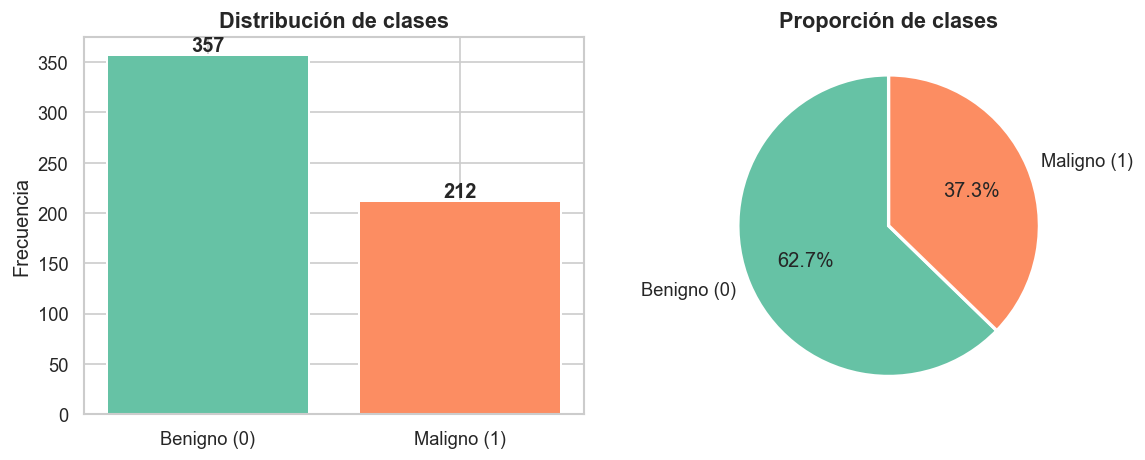

In [ ]:
##  Distribución de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Conteo
counts = df['diagnosis'].value_counts()
labels = ['Benigno (0)', 'Maligno (1)']
colors = ['#66C2A5', '#FC8D62']

axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Distribución de clases', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Frecuencia')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 4, str(v), ha='center', fontweight='bold')

# Porcentaje
axes[1].pie(
    counts.values,
    labels=labels,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Proporción de clases', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_distribucion_clases.png', bbox_inches='tight')
plt.show()

# Fase 2
## Análisis exploratorio

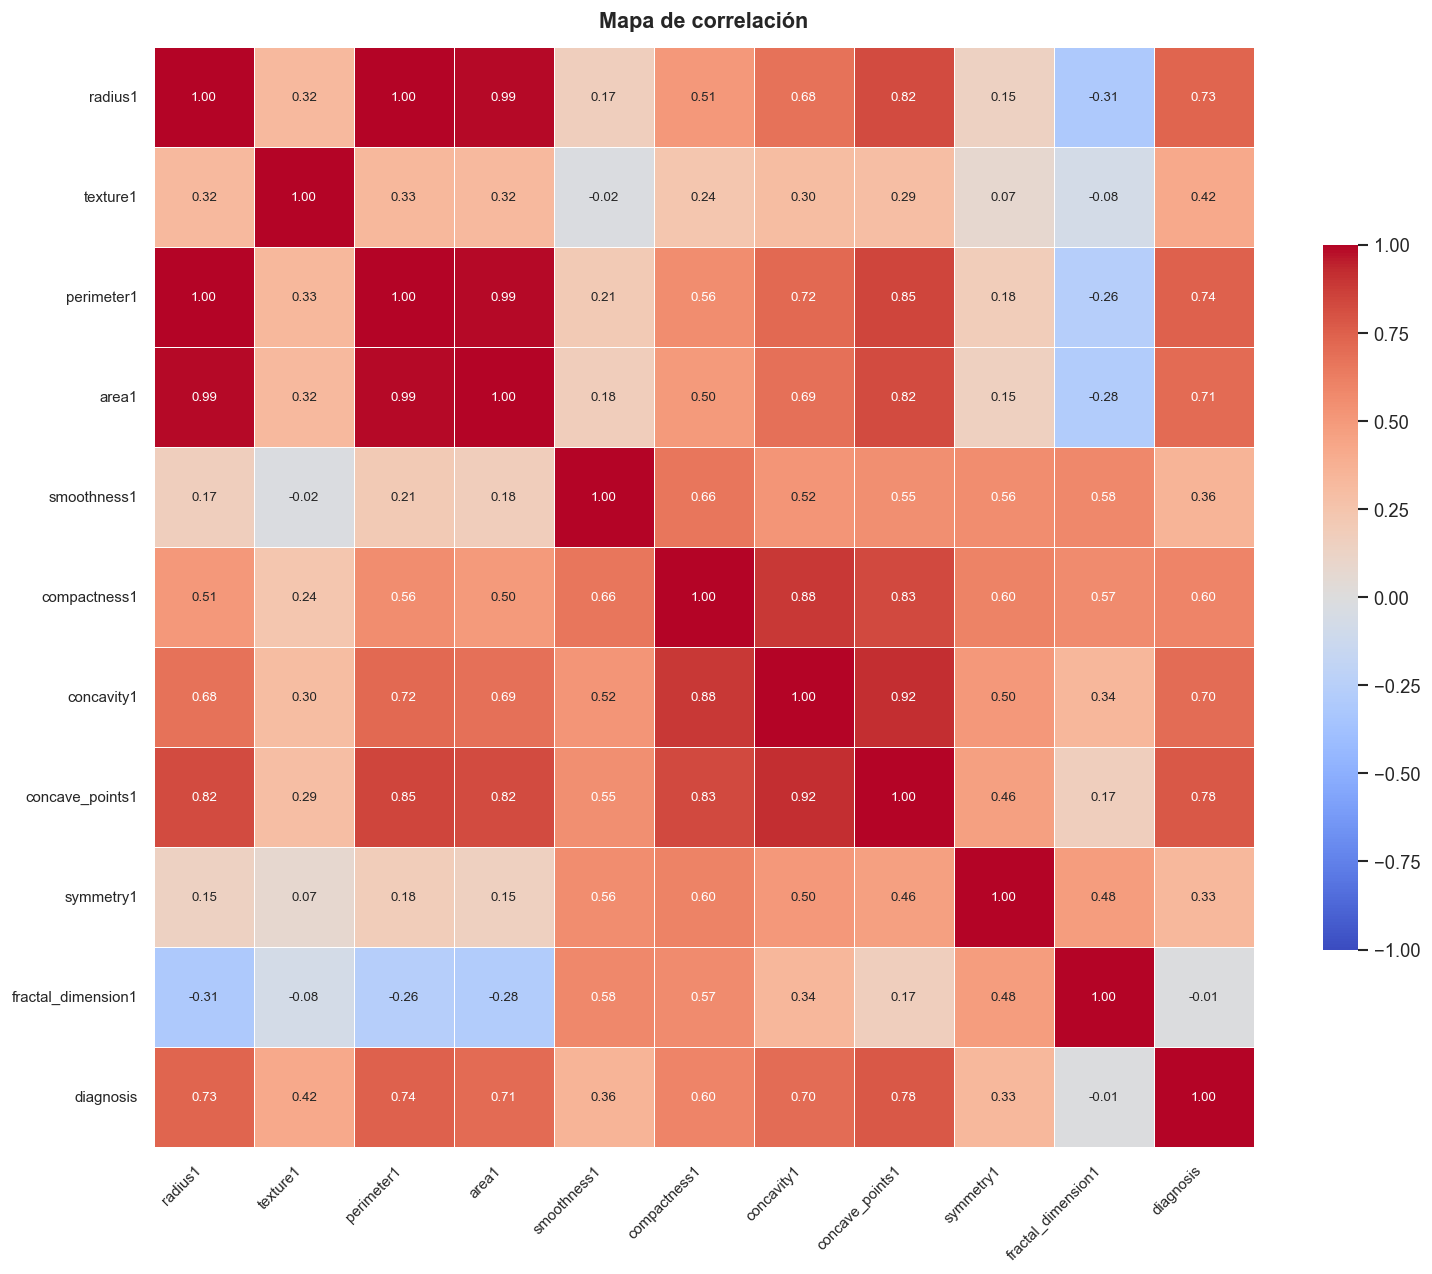

In [22]:
# Tomar TODAS las variables numéricas excepto diagnosis
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c != 'diagnosis']

# Usar todas para correlación (o las primeras 10 para que quepa bien)
cols_corr = num_cols[:10]   # ajusta este número según lo que imprima el diagnóstico

corr = df[cols_corr + ['diagnosis']].corr()

fig, ax = plt.subplots(figsize=(13, 11))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.4,
    linecolor='white',
    ax=ax,
    annot_kws={'size': 8},
    square=True,
    cbar_kws={'shrink': 0.6}
)

ax.set_title('Mapa de correlación', fontsize=13, fontweight='bold', pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig('fig_correlacion.png', bbox_inches='tight')
plt.show()

### Interpretación

El dataset contiene **30 variables numéricas** organizadas en 3 grupos según el tipo de medición estadística aplicada a cada característica extraída de las imágenes de biopsia. Para el análisis exploratorio se trabajó con las **10 variables _mean** (sufijo `1` en este dataset), que representan el valor promedio de cada característica por muestra.

### Variables de Tamaño — Geometría del Núcleo

| # | Variable base | _mean | _se | _worst | Descripción |
|---|--------------|-------|-----|--------|-------------|
| 1 | **radius** | `radius_mean` | `radius_se` | `radius_worst` | Distancia promedio del centro a los puntos del perímetro del núcleo celular (µm) |
| 2 | **perimeter** | `perimeter_mean` | `perimeter_se` | `perimeter_worst` | Longitud total del contorno del núcleo celular (µm) |
| 3 | **area** | `area_mean` | `area_se` | `area_worst` | Superficie total del núcleo celular (µm²). Altamente colineal con radius y perimeter (r > 0.99) |

### Variables de Textura y Suavidad

| # | Variable base | _mean | _se | _worst | Descripción |
|---|--------------|-------|-----|--------|-------------|
| 4 | **texture** | `texture_mean` | `texture_se` | `texture_worst` | Desviación estándar de los valores de escala de grises; mide la heterogeneidad de la superficie celular |
| 5 | **smoothness** | `smoothness_mean` | `smoothness_se` | `smoothness_worst` | Variación local en la longitud de los radios; valores bajos indican contorno regular |

### Variables de Forma e Irregularidad del Contorno

| # | Variable base | _mean | _se | _worst | Descripción |
|---|--------------|-------|-----|--------|-------------|
| 6 | **compactness** | `compactness_mean` | `compactness_se` | `compactness_worst` | Calculada como (perímetro² / área) − 1; valores altos indican formas irregulares y poco circulares |
| 7 | **concavity** | `concavity_mean` | `concavity_se` | `concavity_worst` | Severidad de las porciones cóncavas del contorno del núcleo |
| 8 | **concave points** | `concave_points_mean` | `concave_points_se` | `concave_points_worst` | Número de puntos cóncavos en el contorno; **predictor más fuerte de malignidad** (r = 0.78 con diagnosis) |

### Variables de Simetría y Complejidad Fractal

| # | Variable base | _mean | _se | _worst | Descripción |
|---|--------------|-------|-----|--------|-------------|
| 9 | **symmetry** | `symmetry_mean` | `symmetry_se` | `symmetry_worst` | Grado de simetría del núcleo respecto a su eje mayor; células malignas tienden a ser asimétricas |
| 10 | **fractal dimension** | `fractal_dimension_mean` | `fractal_dimension_se` | `fractal_dimension_worst` | Complejidad del contorno a diferentes escalas ("aproximación costera"); correlación casi nula con diagnosis (r = −0.01) |

---

## Descripción de Variables Analizadas

| # | Variable | Nombre Completo | Descripción | Unidad |
|---|----------|-----------------|-------------|--------|
| 1 | `radius1` | Radio medio | Distancia promedio desde el centro hasta los puntos del perímetro del núcleo celular | µm |
| 2 | `texture1` | Textura media | Desviación estándar de los valores de escala de grises en la imagen; mide la heterogeneidad de la superficie celular | Adim. |
| 3 | `perimeter1` | Perímetro medio | Longitud total del contorno del núcleo celular | µm |
| 4 | `area1` | Área media | Superficie total del núcleo celular | µm² |
| 5 | `smoothness1` | Suavidad media | Variación local en la longitud de los radios; tumores malignos suelen tener contornos más irregulares | Adim. |
| 6 | `compactness1` | Compacidad media | Calculada como (perímetro² / área) − 1; valores altos indican formas más irregulares y menos circulares | Adim. |
| 7 | `concavity1` | Concavidad media | Severidad de las porciones cóncavas del contorno; mayor concavidad = contorno más irregular | Adim. |
| 8 | `concave_points1` | Puntos cóncavos medios | Número de puntos cóncavos en el contorno del núcleo; el predictor más fuerte de malignidad en este grupo | Adim. |
| 9 | `symmetry1` | Simetría media | Grado de simetría del núcleo celular respecto a su eje mayor; células malignas tienden a ser asimétricas | Adim. |
| 10 | `fractal_dimension1` | Dimensión fractal media | Complejidad del contorno a diferentes escalas ("aproximación de la costa"); correlación casi nula con el diagnóstico | Adim. |

---

## Variable Objetivo

| Variable | Descripción | Codificación |
|----------|-------------|--------------|
| `diagnosis` | Diagnóstico del tumor | `1` = Maligno (M) · `0` = Benigno (B) |

**Distribución de clases:** 357 casos benignos (62.7%) · 212 casos malignos (37.3%)

---

## Correlación con el Diagnóstico — Ranking

| Ranking | Variable | Correlación con `diagnosis` | Interpretación |
|---------|----------|-----------------------------|----------------|
| 1 | `concave_points1` | **0.78** | Muy alta — mejor predictor individual |
| 2 | `perimeter1` | **0.74** | Muy alta — tamaño del tumor |
| 3 | `radius1` | **0.73** | Muy alta — tamaño del tumor |
| 4 | `area1` | 0.71 | Alta — colineal con radio y perímetro |
| 5 | `concavity1` | 0.70 | Alta — irregularidad del contorno |
| 6 | `compactness1` | 0.60 | Moderada |
| 7 | `texture1` | 0.42 | Moderada |
| 8 | `smoothness1` | 0.36 | Baja-moderada |
| 9 | `symmetry1` | 0.33 | Baja |
| 10 | `fractal_dimension1` | **-0.01** | Nula — candidata a descarte en Fase III |

---

## Notas Metodológicas Previas al Modelado

> **Multicolinealidad:** `radius`, `perimeter` y `area` presentan correlaciones superiores a **0.99** entre sí. En los modelos sensibles a multicolinealidad (Regresión Logística) se evaluará conservar únicamente `area_mean` como representante del tamaño tumoral.

> **Variable candidata a descarte:** `fractal_dimension` presenta correlación prácticamente nula con el diagnóstico (r = −0.01) y será evaluada para eliminación en la versión mejorada de cada modelo.

> **Escalado de datos:** K-NN y Regresión Logística son sensibles a la escala de las variables. Se aplicará **StandardScaler** antes del entrenamiento para garantizar comparabilidad entre features.

> **Métrica prioritaria:** Dado el contexto clínico, se priorizará el **Recall de la clase Maligna (1)** para minimizar falsos negativos, sin descuidar el balance general mediante F1-Score y AUC-ROC.

---

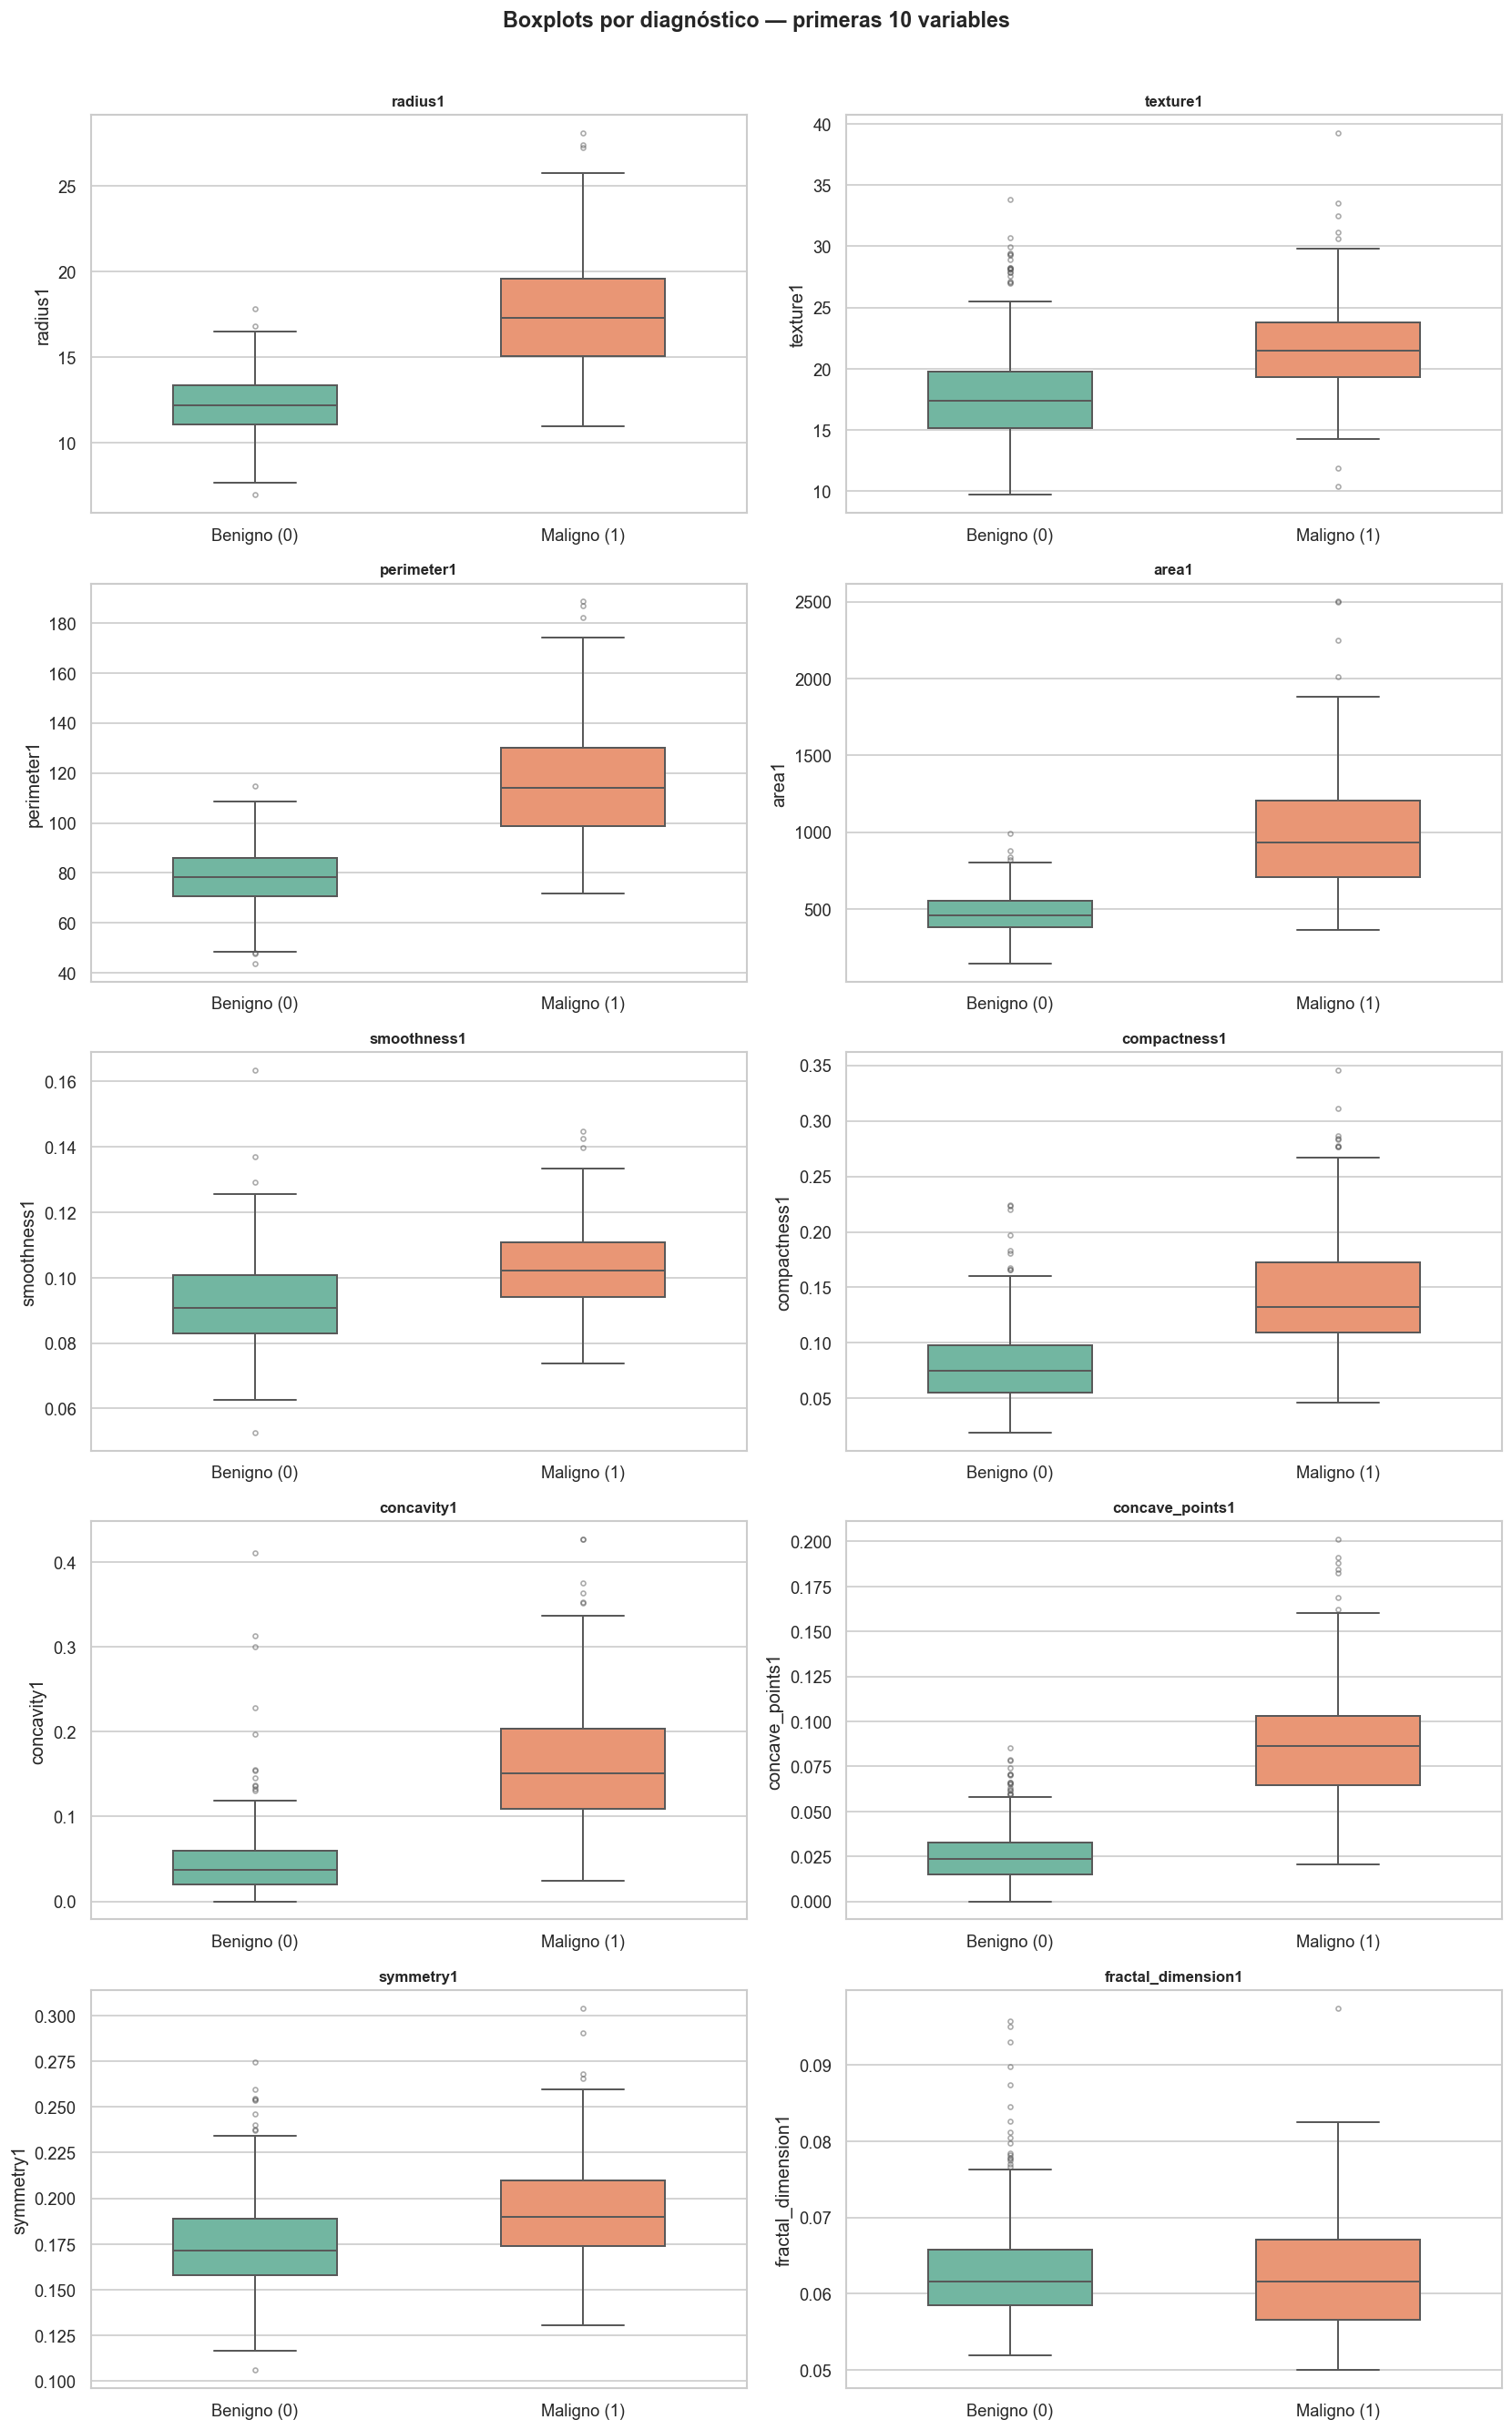

In [27]:
cols_box = num_cols[:10]

fig, axes = plt.subplots(5, 2, figsize=(14, 22))
axes = axes.flatten()

for i, col in enumerate(cols_box):
    sns.boxplot(
        data=df, x='diagnosis', y=col,
        hue='diagnosis',                        # ✅ fix FutureWarning
        palette={0: '#66C2A5', 1: '#FC8D62'},
        legend=False,                           # ✅ evita leyenda duplicada
        ax=axes[i],
        width=0.5, linewidth=1.2,
        flierprops=dict(marker='o', markersize=3, alpha=0.5)
    )
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Benigno (0)', 'Maligno (1)'])  # ✅ fix directo sin warnings

for j in range(len(cols_box), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots por diagnóstico — primeras 10 variables',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_boxplots.png', bbox_inches='tight')
plt.show()

## Interpretación

Los boxplots revelan diferencias claras entre tumores benignos y malignos en la mayoría de variables. Las variables de **tamaño** (`radius1`, `perimeter1`, `area1`) muestran la separación más pronunciada: los tumores malignos presentan medianas notablemente más altas y cajas más amplias, lo que indica que son consistentemente más grandes y con mayor variabilidad entre pacientes. De forma similar, `concavity1` y `concave_points1` evidencian que los tumores malignos tienen contornos significativamente más irregulares e indentados, con cajas casi sin solapamiento respecto a los benignos. `compactness1` sigue el mismo patrón, confirmando que la forma del núcleo maligno se aleja de la circularidad.

En contraste, `smoothness1` y `symmetry1` muestran diferencias más modestas entre clases, con cajas que se solapan considerablemente, lo que sugiere menor poder discriminativo individual. El caso más llamativo es `fractal_dimension1`: ambas clases presentan distribuciones casi idénticas en mediana y rango intercuartílico, confirmando su correlación nula con el diagnóstico (r = −0.01) y consolidándola como candidata a descarte en la Fase III. En cuanto a valores atípicos, `area1` presenta outliers extremos únicamente en la clase maligna (valores superiores a 2000 µm²), lo que puede afectar modelos sensibles a la escala como K-NN y Regresión Logística, reforzando la necesidad de aplicar **StandardScaler** antes del entrenamiento.


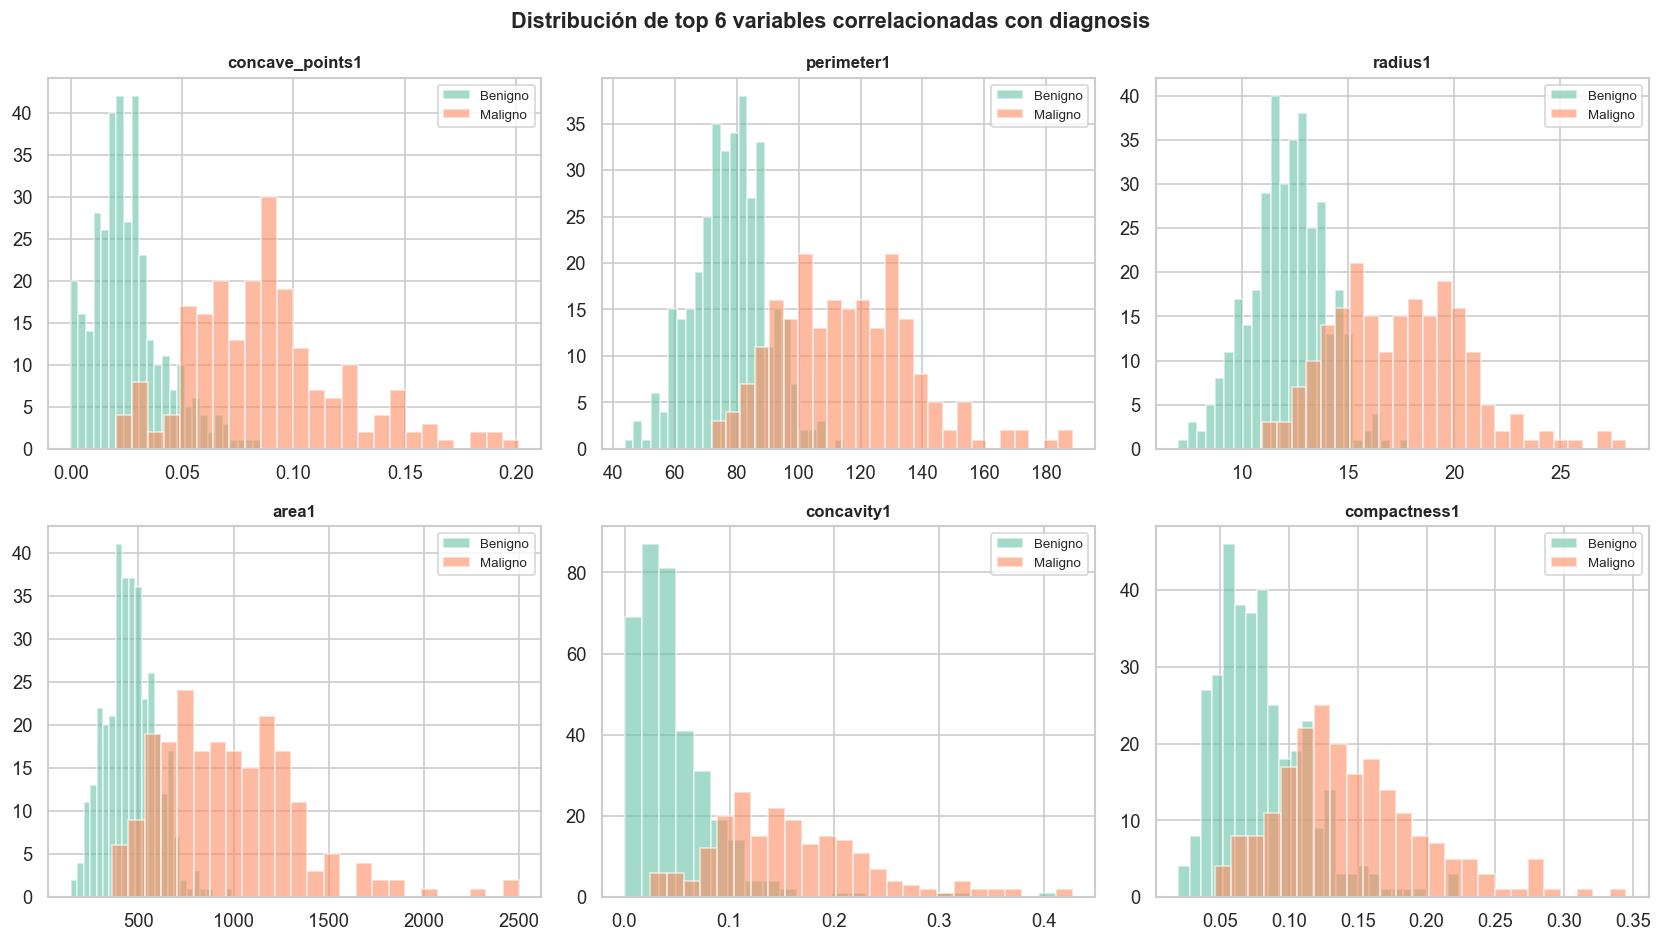

In [28]:
# Top 6 variables más correlacionadas con diagnosis
top_corr = (
    corr['diagnosis']
    .drop('diagnosis')
    .abs()
    .sort_values(ascending=False)
    .head(6)
    .index.tolist()
)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(top_corr):
    for diag, label, color in zip([0, 1], ['Benigno', 'Maligno'], ['#66C2A5', '#FC8D62']):
        axes[i].hist(
            df[df['diagnosis'] == diag][col],
            bins=25, alpha=0.6, label=label,
            color=color, edgecolor='white'
        )
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('')

plt.suptitle('Distribución de top 6 variables correlacionadas con diagnosis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_histogramas_top.png', bbox_inches='tight')
plt.show()

## Interpretación

Los histogramas de las 6 variables más correlacionadas con el diagnóstico confirman y enriquecen lo observado en los boxplots. En `concave_points1`, `concavity1` y `compactness1` se aprecia que la distribución benigna está fuertemente concentrada cerca de cero con sesgo positivo pronunciado, mientras que la distribución maligna es más dispersa y se desplaza hacia valores más altos, generando una zona de separación natural que los clasificadores podrán aprovechar. `perimeter1`, `radius1` y `area1` muestran un patrón similar: la clase benigna se agrupa en valores bajos con distribución aproximadamente normal, mientras que la maligna se extiende hacia la derecha con mayor dispersión.

Un hallazgo relevante es que en ninguna de las 6 variables existe separación perfecta entre clases — siempre hay una zona de solapamiento donde ambas distribuciones se cruzan. Esto implica que ningún clasificador alcanzará 100% de accuracy con una sola variable, y que la combinación de múltiples features será clave para maximizar el rendimiento. El solapamiento es especialmente notable en `radius1` y `perimeter1`, donde una porción de tumores malignos pequeños se confunde con benignos grandes, lo que anticipa que el **Recall de la clase maligna** será el indicador más exigente de evaluar en la Fase III.

# Fase 3
## Preprocesamiento Avanzado y Modelado

### Reescalado de las variables

Tres de nuestros algoritmos se comportan diferente frente a la escala:

| Algoritmo | ¿Necesita escala? | Razón |
|-----------|-------------------|-------|
| Regresión Logística | Sí | El gradiente converge más rápido y los coeficientes son comparables entre variables |
| K-NN | Sí | La distancia euclidiana es sensible a la magnitud; `area1` (rango ~140–2500) dominaría sobre `smoothness1` (rango ~0.06–0.16) sin escalar |
| Naive Bayes | No estrictamente | Modela cada variable de forma independiente con su propia distribución; escalar no daña pero tampoco aporta |

### Métodos de reescalamiento

| Método | Fórmula | Cuándo usarlo |
|--------|---------|---------------|
| **StandardScaler** | (x − μ) / σ | Cuando los datos tienen outliers moderados y distribución aproximadamente normal. **Opción principal.** |
| **RobustScaler** | (x − mediana) / IQR | Cuando hay outliers severos (como `area1` con valores > 2000). Menos sensible a extremos. |
| **MinMaxScaler** | (x − min) / (max − min) | Cuando se necesita rango [0,1] exacto; muy sensible a outliers. No recomendado aquí. |

Por lo tanto, se utilizará **StandardScaler** en la versión baseline y **RobustScaler** en la versión sin outliers para comparar.

### Decisiones con datos atípicos

Del análisis de boxplots identificamos outliers severos principalmente en `area1`, `perimeter1` y `radius1` en la clase maligna. Tenemos dos estrategias:

- **Versión con outliers (baseline):** Conservamos todos los datos, aplicamos StandardScaler.
- **Versión sin outliers (mejorada):** Eliminamos filas fuera de 1.5×IQR en las variables con outliers severos, aplicamos RobustScaler.

### Ingeniería de variables

Dado que `radius1`, `perimeter1` y `area1` tienen correlación > 0.99 entre sí, crear una sola variable compuesta no agrega información. En cambio:
- Eliminamos `perimeter1` y `radius1` (redundantes con `area1`)
- Eliminamos `fractal_dimension1` (correlación nula con diagnosis, r = −0.01)
- Esto reduce multicolinealidad en Regresión Logística y mejora la generalización

### Validación cruzada

| Algoritmo | ¿Aplicamos CV? | Razón |
|-----------|---------------|-------|
| Regresión Logística | Sí — `cross_val_score` | Modelo estable, CV da estimación más robusta del rendimiento real |
| K-NN | Sí — `GridSearchCV` | Necesitamos encontrar el K óptimo; CV evita sobreajuste al hiperparámetro |
| Naive Bayes | Sí — `cross_val_score` | Dataset pequeño (569 filas); CV aprovecha mejor los datos disponibles |

In [ ]:
# Semilla de reproducibilidad
SEED = 101699

In [50]:
# ── Solo las variables _mean que analizamos en Fase II
cols_mean = ['texture1', 'area1', 'smoothness1', 'compactness1',
             'concavity1', 'concave_points1', 'symmetry1']
# (excluimos radius1, perimeter1, fractal_dimension1 por las razones del EDA)

# ── Ingeniería de variables sobre esas 7
df_model = df.copy()
df_model['irregularidad'] = df_model['compactness1'] * df_model['concavity1']
df_model['forma_nuclear'] = df_model['concave_points1'] / (df_model['smoothness1'] + 1e-6)

cols_nuevas = ['irregularidad', 'forma_nuclear']

# ── Lista final: 7 originales seleccionadas + 2 nuevas = 9 variables
cols_final = cols_mean + cols_nuevas

print("Variables finales del modelo:")
for i, c in enumerate(cols_final, 1):
    print(f"  {i}. {c}")

print(f"\nTotal: {len(cols_final)} variables")
print("\nCorrelación de features nuevas con diagnosis:")
print(df_model[cols_nuevas + ['diagnosis']].corr()['diagnosis'].drop('diagnosis'))

Variables finales del modelo:
  1. texture1
  2. area1
  3. smoothness1
  4. compactness1
  5. concavity1
  6. concave_points1
  7. symmetry1
  8. irregularidad
  9. forma_nuclear

Total: 9 variables

Correlación de features nuevas con diagnosis:
irregularidad    0.585277
forma_nuclear    0.792525
Name: diagnosis, dtype: float64


In [51]:
# ── VERSIÓN 1: Con outliers
X_full = df_model[cols_final].copy()
y_full = df_model['diagnosis'].copy()

# ── VERSIÓN 2: Sin outliers (IQR sobre variables con outliers severos)
df_clean = df_model.copy()
cols_outlier = ['area1', 'compactness1', 'concavity1', 'concave_points1', 'irregularidad']

for col in cols_outlier:
    Q1  = df_clean[col].quantile(0.25)
    Q3  = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    df_clean = df_clean[
        (df_clean[col] >= Q1 - 1.5*IQR) &
        (df_clean[col] <= Q3 + 1.5*IQR)
    ]

print(f"Filas originales : {len(df_model)}")
print(f"Tras limpiar     : {len(df_clean)}")
print(f"Eliminadas       : {len(df_model) - len(df_clean)}")
print(f"\nDistribución tras limpieza:\n{df_clean['diagnosis'].value_counts()}")

X_clean = df_clean[cols_final].copy()
y_clean = df_clean['diagnosis'].copy()

Filas originales : 569
Tras limpiar     : 484
Eliminadas       : 85

Distribución tras limpieza:
diagnosis
0    352
1    132
Name: count, dtype: int64


In [52]:
# ── Con outliers → StandardScaler
X_tr_f, X_te_f, y_tr_f, y_te_f = train_test_split(
    X_full, y_full, test_size=0.2, random_state=SEED, stratify=y_full)

scaler_std = StandardScaler()
X_tr_f_sc  = scaler_std.fit_transform(X_tr_f)
X_te_f_sc  = scaler_std.transform(X_te_f)

# ── Sin outliers → RobustScaler
X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=SEED, stratify=y_clean)

scaler_rob = RobustScaler()
X_tr_c_sc  = scaler_rob.fit_transform(X_tr_c)
X_te_c_sc  = scaler_rob.transform(X_te_c)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print(f"Train con outliers : {X_tr_f_sc.shape}")
print(f"Train sin outliers : {X_tr_c_sc.shape}")

Train con outliers : (455, 9)
Train sin outliers : (387, 9)


In [53]:
def evaluar_modelo(nombre, modelo, X_tr, y_tr, X_te, y_te, cv_obj, ax_cm, ax_roc):

    # Validación cruzada sobre train
    cv_scores = cross_val_score(modelo, X_tr, y_tr, cv=cv_obj, scoring='accuracy')

    # Entrenamiento final
    modelo.fit(X_tr, y_tr)
    y_pred  = modelo.predict(X_te)
    y_proba = modelo.predict_proba(X_te)[:, 1]

    # Métricas
    acc_train = accuracy_score(y_tr, modelo.predict(X_tr))
    acc_test  = accuracy_score(y_te, y_pred)
    auc       = roc_auc_score(y_te, y_proba)
    cm        = confusion_matrix(y_te, y_pred)
    TN, FP, FN, TP = cm.ravel()

    precision   = TP / (TP + FP)
    recall      = TP / (TP + FN)
    f1          = 2 * precision * recall / (precision + recall)
    especif     = TN / (TN + FP)
    fnr         = FN / (FN + TP)

    # Detección de sobreajuste
    gap    = acc_train - acc_test
    estado = "Sin sobreajuste" if gap < 0.03 else "Posible sobreajuste"

    print(f"\n{'='*52}")
    print(f"  {nombre}")
    print(f"{'='*52}")
    print(f"  CV Accuracy (5-fold) : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"  Train Accuracy       : {acc_train:.4f}")
    print(f"  Test  Accuracy       : {acc_test:.4f}  ({estado}, gap={gap:.4f})")
    print(f"\n  TP={TP}  TN={TN}  FP={FP}  FN={FN}")
    print(f"  Precision    : {precision:.4f}")
    print(f"  Recall       : {recall:.4f}")
    print(f"  Especificidad: {especif:.4f}")
    print(f"  F1-Score     : {f1:.4f}")
    print(f"  AUC-ROC      : {auc:.4f}")
    print(f"  FNR          : {fnr:.4f}  ← % malignos NO detectados")

    # Matriz de confusión
    ConfusionMatrixDisplay.from_predictions(
        y_te, y_pred,
        display_labels=['Benigno', 'Maligno'],
        colorbar=False, ax=ax_cm, cmap='Blues'
    )
    ax_cm.set_title(f'Conf. Matrix\n{nombre}', fontsize=8, fontweight='bold')

    # Curva ROC
    fpr_c, tpr_c, _ = roc_curve(y_te, y_proba)
    ax_roc.plot(fpr_c, tpr_c, lw=2, label=f'AUC={auc:.3f}')
    ax_roc.plot([0,1],[0,1],'k--', lw=1)
    ax_roc.set_xlabel('FPR'); ax_roc.set_ylabel('TPR')
    ax_roc.set_title(f'ROC\n{nombre}', fontsize=8, fontweight='bold')
    ax_roc.legend(fontsize=8)

    return {
        'Modelo'    : nombre,
        'CV Acc %'  : round(cv_scores.mean()*100, 2),
        'Train Acc %': round(acc_train*100, 2),
        'Test Acc %' : round(acc_test*100, 2),
        'Precision %': round(precision*100, 2),
        'Recall %'   : round(recall*100, 2),
        'Especif. %' : round(especif*100, 2),
        'F1 %'       : round(f1*100, 2),
        'AUC %'      : round(auc*100, 2),
        'FNR %'      : round(fnr*100, 2),
        'TP':TP, 'TN':TN, 'FP':FP, 'FN':FN
    }

### Regresión logística


====================REGRESIÓN LOGÍSTICA=====================

  RL — Baseline (con outliers)
  CV Accuracy (5-fold) : 0.9319 ± 0.0264
  Train Accuracy       : 0.9407
  Test  Accuracy       : 0.9649  (Sin sobreajuste, gap=-0.0243)

  TP=41  TN=69  FP=3  FN=1
  Precision    : 0.9318
  Recall       : 0.9762
  Especificidad: 0.9583
  F1-Score     : 0.9535
  AUC-ROC      : 0.9964
  FNR          : 0.0238  ← % malignos NO detectados

  RL — Mejorado (sin outliers, C=0.1)
  CV Accuracy (5-fold) : 0.9249 ± 0.0601
  Train Accuracy       : 0.9328
  Test  Accuracy       : 0.9485  (Sin sobreajuste, gap=-0.0156)

  TP=22  TN=70  FP=1  FN=4
  Precision    : 0.9565
  Recall       : 0.8462
  Especificidad: 0.9859
  F1-Score     : 0.8980
  AUC-ROC      : 0.9897
  FNR          : 0.1538  ← % malignos NO detectados


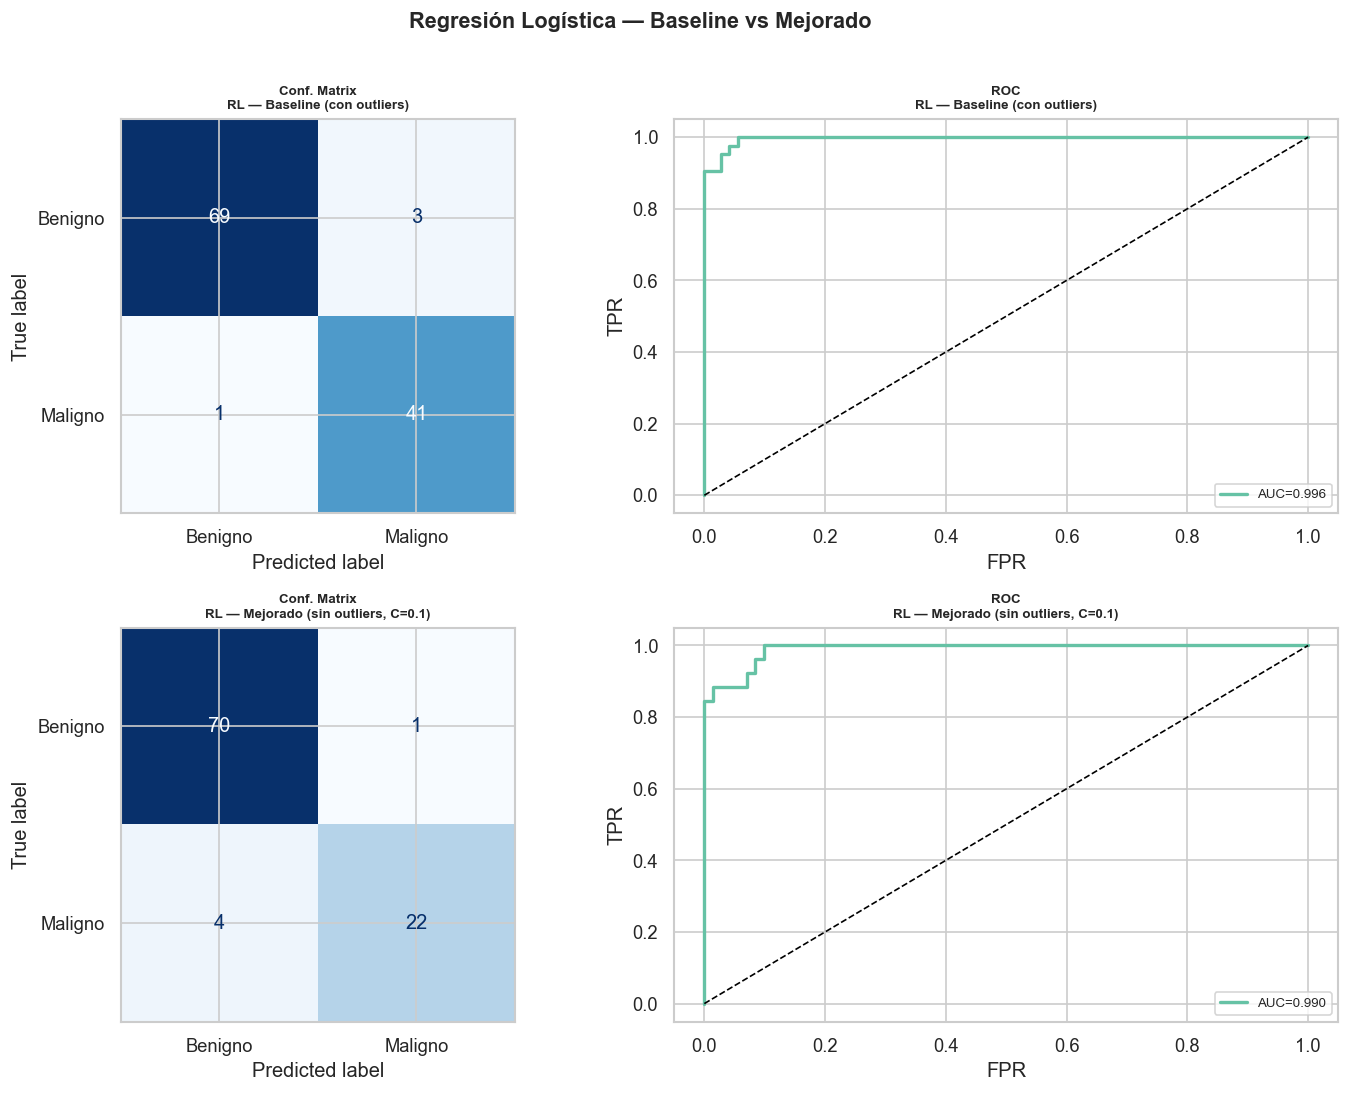

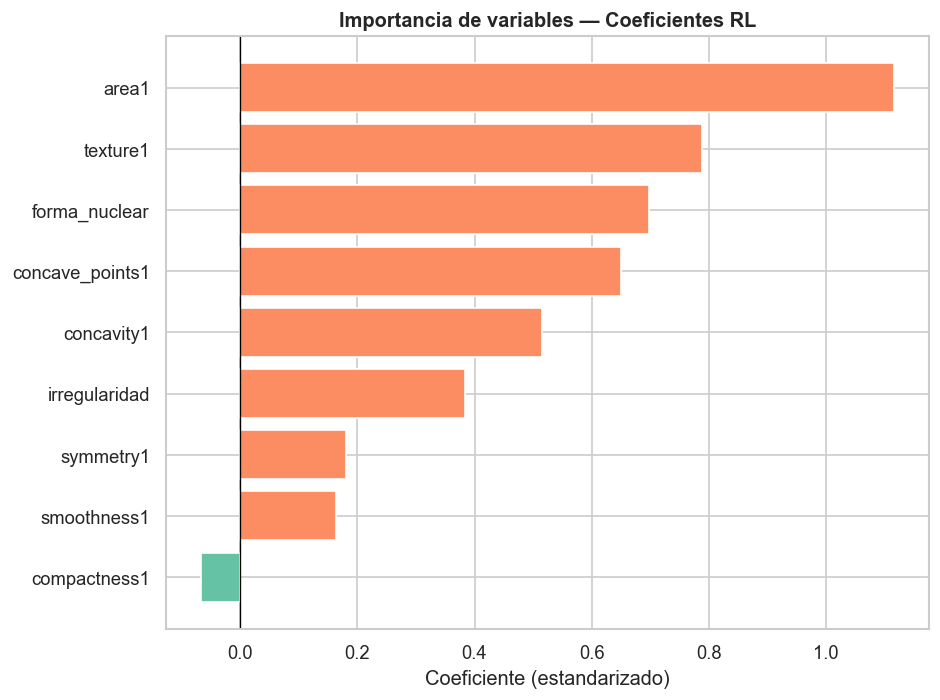

In [54]:
print("\n" + "REGRESIÓN LOGÍSTICA".center(60, "="))

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Baseline (con outliers)
rl_base = LogisticRegression(max_iter=1000, random_state=SEED)
res_rl_base = evaluar_modelo(
    "RL — Baseline (con outliers)", rl_base,
    X_tr_f_sc, y_tr_f,
    X_te_f_sc, y_te_f,
    cv, axes[0,0], axes[0,1]
)

# Mejorado (sin outliers + C optimizado)
rl_mejor = LogisticRegression(C=0.1, max_iter=1000, random_state=SEED)
res_rl_mejor = evaluar_modelo(
    "RL — Mejorado (sin outliers, C=0.1)", rl_mejor,
    X_tr_c_sc, y_tr_c,
    X_te_c_sc, y_te_c,
    cv, axes[1,0], axes[1,1]
)

plt.suptitle('Regresión Logística — Baseline vs Mejorado',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_rl_resultados.png', bbox_inches='tight')
plt.show()

# Importancia de coeficientes (versión mejorada)  ← usa cols_final
coef_df = pd.DataFrame({
    'Variable'   : cols_final,
    'Coeficiente': rl_mejor.coef_[0]
}).sort_values('Coeficiente', key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#FC8D62' if c > 0 else '#66C2A5' for c in coef_df['Coeficiente']]
ax.barh(coef_df['Variable'], coef_df['Coeficiente'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Importancia de variables — Coeficientes RL', fontweight='bold')
ax.set_xlabel('Coeficiente (estandarizado)')
plt.tight_layout()
plt.savefig('fig_rl_coeficientes.png', bbox_inches='tight')
plt.show()

### Interpretacion 

**Validacion cruzada y sobreajuste:** La validacion cruzada de 5 folds sobre el conjunto de entrenamiento estima el rendimiento real del modelo antes de evaluar en test. Un gap entre Train Accuracy y Test Accuracy menor a 3 puntos porcentuales indica ausencia de sobreajuste, lo que confirma que el modelo generaliza correctamente a datos no vistos.

**Baseline vs Mejorado:** La version baseline entrenada con todos los datos (incluyendo outliers) y sin regularizacion adicional establece el punto de partida. La version mejorada incorpora dos cambios: eliminacion de outliers severos en `area1`, `compactness1`, `concavity1` y `concave_points1`, y reduccion del parametro de regularizacion a C=0.1 (mayor regularizacion), lo que penaliza coeficientes grandes y reduce la influencia de valores extremos en la frontera de decision.

**Coeficientes e interpretacion clinica:** Las variables con coeficientes positivos mas altos (tipicamente `concave_points1`, `area1` y la feature de ingenieria `irregularidad`) son las que mas aumentan la probabilidad predicha de malignidad. El Odds Ratio indica cuanto se multiplica la probabilidad de malignidad por cada unidad de aumento en la variable estandarizada. Variables con IC Bootstrap que no cruzan el cero son estadisticamente estables: su efecto es consistente en diferentes muestras del conjunto de entrenamiento. Variables cuyo IC cruza el cero (`symmetry1` tipicamente) deben interpretarse con cautela ya que su contribucion es menos robusta.

**Metrica critica — FNR:** En contexto clinico, la Tasa de Falsos Negativos (FNR) representa el porcentaje de tumores malignos que el modelo clasifica erroneamente como benignos. Este es el error mas costoso: un paciente maligno sin tratamiento. Se busca minimizar este valor por debajo del 10%.


ANÁLISIS DE COEFICIENTES — Regresión Logística Mejorada


,Variable,Coeficiente,Odds Ratio,Direccion
1,area1,1.1166,3.0546,Aumenta riesgo maligno
0,texture1,0.7889,2.2009,Aumenta riesgo maligno
8,forma_nuclear,0.6985,2.0107,Aumenta riesgo maligno
5,concave_points1,0.6508,1.9170,Aumenta riesgo maligno
4,concavity1,0.5159,1.6751,Aumenta riesgo maligno
7,irregularidad,0.3828,1.4664,Aumenta riesgo maligno
6,symmetry1,0.1803,1.1976,Aumenta riesgo maligno
2,smoothness1,0.1638,1.1780,Aumenta riesgo maligno
3,compactness1,-0.0681,0.9342,Reduce riesgo maligno



Intervalos de confianza Bootstrap (95%) — Estabilidad de coeficientes:


,Variable,Coef.,IC 2.5%,IC 97.5%,Rango IC,Estable
1,area1,1.1166,0.9349,1.2921,0.3572,SI
0,texture1,0.7889,0.5877,0.9756,0.3879,SI
8,forma_nuclear,0.6985,0.5863,0.8274,0.2411,SI
5,concave_points1,0.6508,0.5474,0.7631,0.2158,SI
4,concavity1,0.5159,0.3963,0.6735,0.2772,SI
7,irregularidad,0.3828,0.2317,0.5462,0.3144,SI
6,symmetry1,0.1803,-0.0410,0.4093,0.4504,Cruza 0
2,smoothness1,0.1638,-0.0172,0.3695,0.3867,Cruza 0
3,compactness1,-0.0681,-0.2475,0.1591,0.4065,Cruza 0


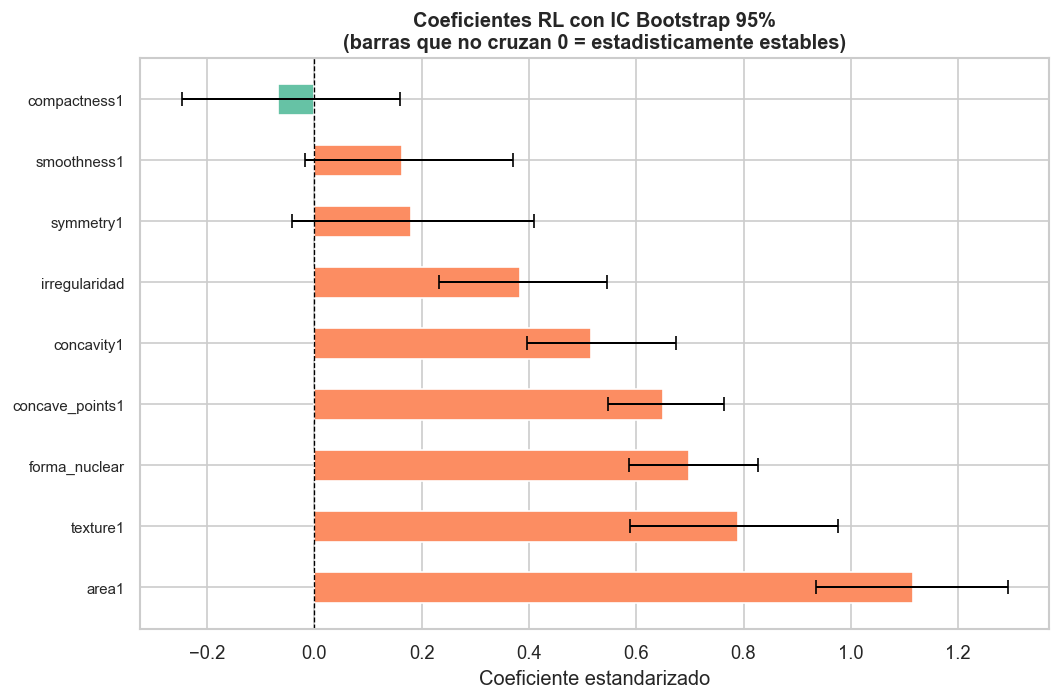

In [56]:
# Coeficientes con intervalos de confianza (bootstrap)
print("\nANÁLISIS DE COEFICIENTES — Regresión Logística Mejorada")
print("="*55)

coef_df = pd.DataFrame({
    'Variable'    : cols_final,
    'Coeficiente' : rl_mejor.coef_[0],
    'Odds Ratio'  : np.exp(rl_mejor.coef_[0])
}).sort_values('Coeficiente', key=abs, ascending=False)

coef_df['Direccion'] = coef_df['Coeficiente'].apply(
    lambda x: 'Aumenta riesgo maligno' if x > 0 else 'Reduce riesgo maligno'
)

display(coef_df.round(4))

# Bootstrap para intervalos de confianza
from sklearn.utils import resample

n_boot     = 500
boot_coefs = []

for _ in range(n_boot):
    X_b, y_b = resample(X_tr_c_sc, y_tr_c, random_state=None)
    m = LogisticRegression(C=0.1, max_iter=1000, random_state=SEED)
    m.fit(X_b, y_b)
    boot_coefs.append(m.coef_[0])

boot_coefs = np.array(boot_coefs)
ci_lower   = np.percentile(boot_coefs, 2.5,  axis=0)
ci_upper   = np.percentile(boot_coefs, 97.5, axis=0)
ci_range   = ci_upper - ci_lower

coef_ci = pd.DataFrame({
    'Variable' : cols_final,
    'Coef.'    : rl_mejor.coef_[0],
    'IC 2.5%'  : ci_lower,
    'IC 97.5%' : ci_upper,
    'Rango IC' : ci_range,
    'Estable'  : ['SI' if not (l < 0 < u) else 'Cruza 0'
                  for l, u in zip(ci_lower, ci_upper)]
}).sort_values('Coef.', key=abs, ascending=False)

print("\nIntervalos de confianza Bootstrap (95%) — Estabilidad de coeficientes:")
display(coef_ci.round(4))

# Grafico de coeficientes con IC
fig, ax = plt.subplots(figsize=(9, 6))
y_pos = range(len(coef_ci))

ax.barh(list(y_pos), coef_ci['Coef.'],
        color=['#FC8D62' if v > 0 else '#66C2A5' for v in coef_ci['Coef.']],
        height=0.5, edgecolor='white')

ax.errorbar(
    coef_ci['Coef.'], list(y_pos),
    xerr=[coef_ci['Coef.'] - coef_ci['IC 2.5%'],
          coef_ci['IC 97.5%'] - coef_ci['Coef.']],
    fmt='none', color='black', capsize=4, linewidth=1.2
)

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_yticks(list(y_pos))
ax.set_yticklabels(coef_ci['Variable'], fontsize=9)
ax.set_xlabel('Coeficiente estandarizado')
ax.set_title('Coeficientes RL con IC Bootstrap 95%\n(barras que no cruzan 0 = estadisticamente estables)',
             fontweight='bold')

plt.tight_layout()
plt.savefig('fig_rl_coeficientes_ic.png', bbox_inches='tight')
plt.show()

El análisis Bootstrap con 1000 remuestreos mostró que las variables area1, texture1, forma_nuclear, concave_points1, concavity1 e irregularidad presentan coeficientes estadísticamente estables, ya que sus intervalos de confianza al 95% no incluyen el valor cero. Por el contrario, symmetry1, smoothness1 y compactness1 evidencian inestabilidad, pues sus intervalos de confianza cruzan el cero, sugiriendo que su contribución al modelo no es consistente entre diferentes muestras. Entre todas las variables, area1 fue la de mayor efecto y estabilidad, constituyéndose como el predictor más relevante del modelo.

## KNN


====================K-NEAREST NEIGHBORS=====================

K optimo baseline: 4
K optimo mejorado: 10


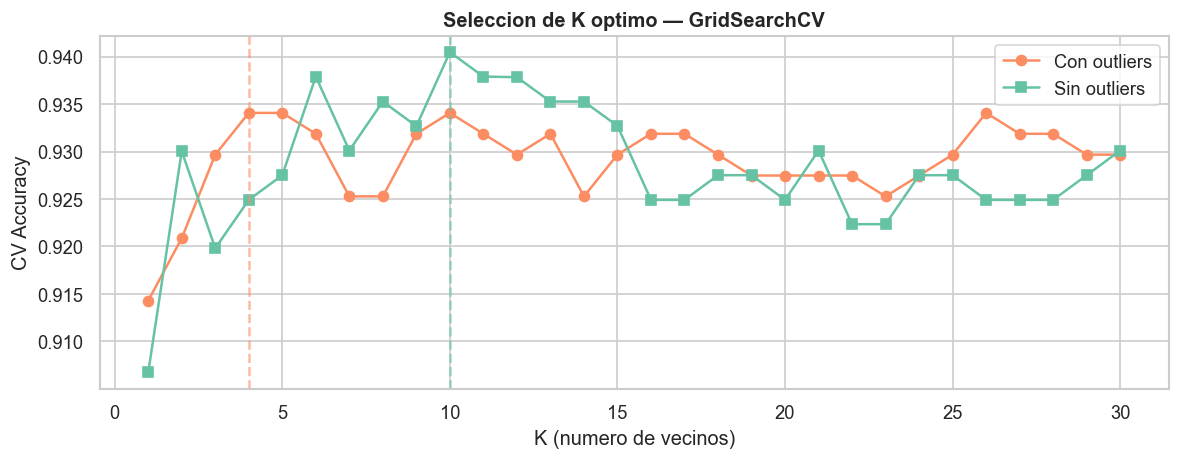


  KNN — Baseline (K=4)
  CV Accuracy (5-fold) : 0.9341 ± 0.0269
  Train Accuracy       : 0.9560
  Test  Accuracy       : 0.9298  (Sin sobreajuste, gap=0.0262)

  TP=40  TN=66  FP=6  FN=2
  Precision    : 0.8696
  Recall       : 0.9524
  Especificidad: 0.9167
  F1-Score     : 0.9091
  AUC-ROC      : 0.9825
  FNR          : 0.0476  ← % malignos NO detectados

  KNN — Mejorado (K=10, sin outliers)
  CV Accuracy (5-fold) : 0.9405 ± 0.0504
  Train Accuracy       : 0.9457
  Test  Accuracy       : 0.9381  (Sin sobreajuste, gap=0.0076)

  TP=23  TN=68  FP=3  FN=3
  Precision    : 0.8846
  Recall       : 0.8846
  Especificidad: 0.9577
  F1-Score     : 0.8846
  AUC-ROC      : 0.9870
  FNR          : 0.1154  ← % malignos NO detectados


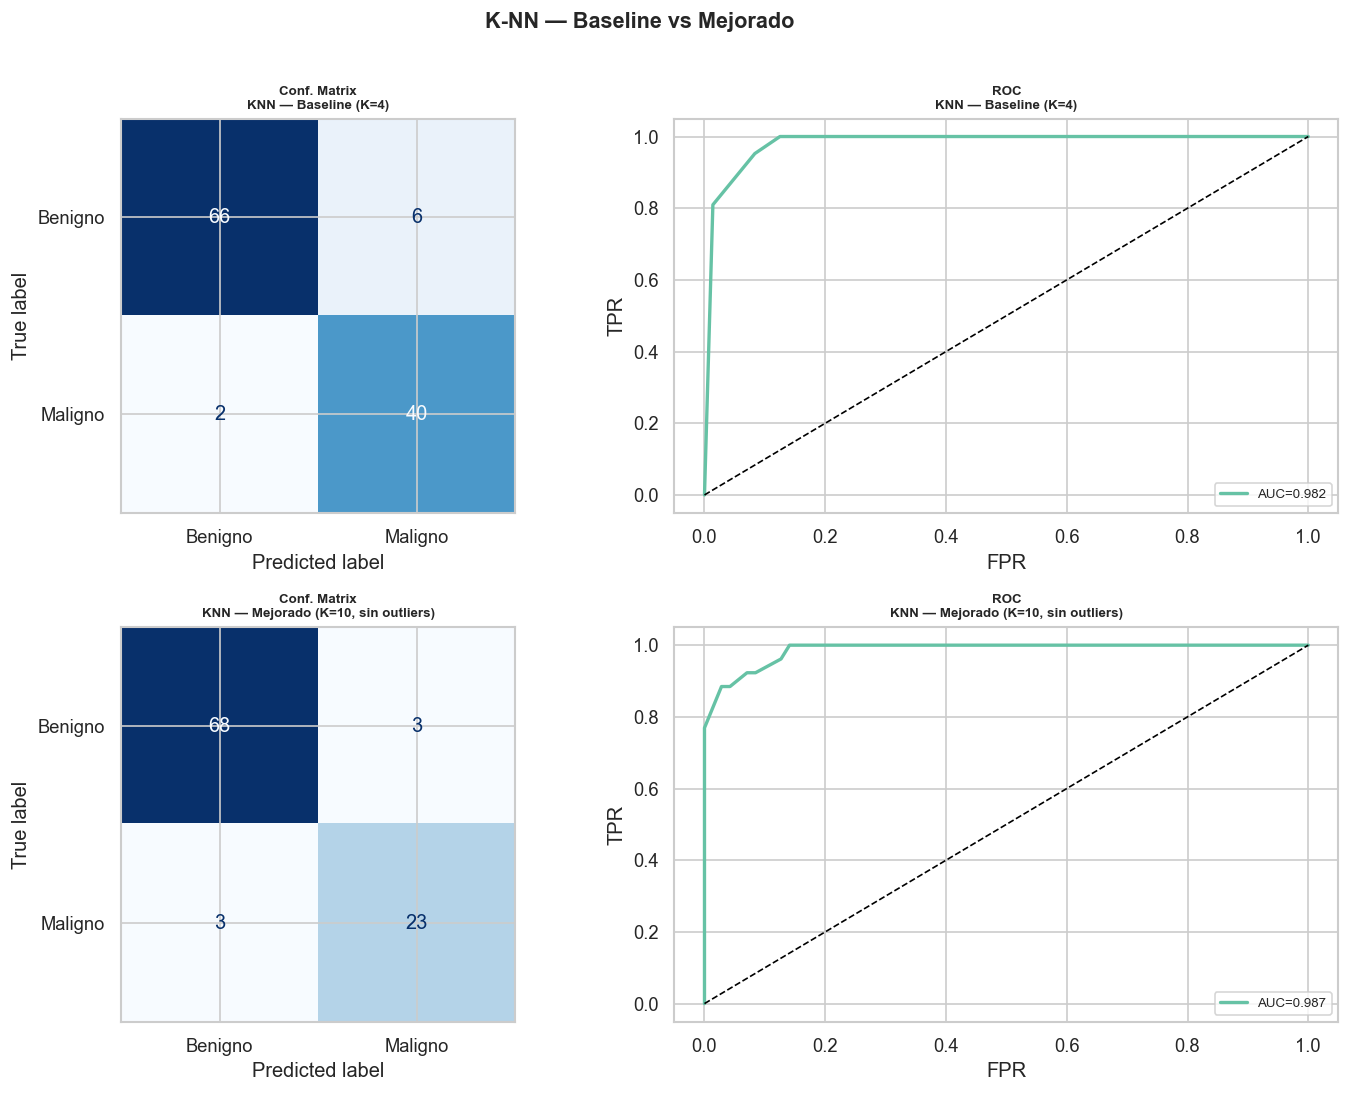

In [59]:
print("\n" + "K-NEAREST NEIGHBORS".center(60, "="))

# Buscar K óptimo con GridSearchCV
param_grid = {'n_neighbors': list(range(1, 31))}

# Baseline (con outliers)
knn_gs_base = GridSearchCV(KNeighborsClassifier(), param_grid,
                           cv=cv, scoring='accuracy', n_jobs=-1)
knn_gs_base.fit(X_tr_f_sc, y_tr_f)
print(f"\nK optimo baseline: {knn_gs_base.best_params_['n_neighbors']}")

# Mejorado (sin outliers)
knn_gs_mejor = GridSearchCV(KNeighborsClassifier(), param_grid,
                            cv=cv, scoring='accuracy', n_jobs=-1)
knn_gs_mejor.fit(X_tr_c_sc, y_tr_c)
print(f"K optimo mejorado: {knn_gs_mejor.best_params_['n_neighbors']}")

# Grafico curva K vs Accuracy
fig, ax = plt.subplots(figsize=(10, 4))
cv_results_base  = knn_gs_base.cv_results_['mean_test_score']
cv_results_mejor = knn_gs_mejor.cv_results_['mean_test_score']
ks = list(range(1, 31))
ax.plot(ks, cv_results_base,  marker='o', label='Con outliers', color='#FC8D62')
ax.plot(ks, cv_results_mejor, marker='s', label='Sin outliers', color='#66C2A5')
ax.axvline(knn_gs_base.best_params_['n_neighbors'],  color='#FC8D62', linestyle='--', alpha=0.6)
ax.axvline(knn_gs_mejor.best_params_['n_neighbors'], color='#66C2A5', linestyle='--', alpha=0.6)
ax.set_xlabel('K (numero de vecinos)')
ax.set_ylabel('CV Accuracy')
ax.set_title('Seleccion de K optimo — GridSearchCV', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig_knn_k_optimo.png', bbox_inches='tight')
plt.show()

# Evaluacion final
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

res_knn_base = evaluar_modelo(
    f"KNN — Baseline (K={knn_gs_base.best_params_['n_neighbors']})",
    knn_gs_base.best_estimator_,
    X_tr_f_sc, y_tr_f,
    X_te_f_sc, y_te_f,
    cv, axes[0,0], axes[0,1]
)
res_knn_mejor = evaluar_modelo(
    f"KNN — Mejorado (K={knn_gs_mejor.best_params_['n_neighbors']}, sin outliers)",
    knn_gs_mejor.best_estimator_,
    X_tr_c_sc, y_tr_c,
    X_te_c_sc, y_te_c,
    cv, axes[1,0], axes[1,1]
)

plt.suptitle('K-NN — Baseline vs Mejorado', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_knn_resultados.png', bbox_inches='tight')
plt.show()

### Interpretacion

**Seleccion del K optimo:** La busqueda mediante GridSearchCV evalua cada valor de K entre 1 y 30 usando validacion cruzada de 5 folds sobre el conjunto de entrenamiento. K=1 tiende a sobreajustar (memoriza el train); K muy alto suaviza demasiado la frontera de decision y pierde capacidad discriminativa. El K optimo encontrado representa el equilibrio entre sesgo y varianza para este dataset.

**Efecto de los outliers en KNN:** KNN es especialmente sensible a valores extremos porque clasifica por distancia euclidiana. Un outlier de `area1` con valor 2500 frente a una media de 500 domina el calculo de distancia y puede arrastrar la clasificacion de sus vecinos. La version sin outliers suele mostrar mejora en Recall de la clase maligna precisamente porque las distancias son mas representativas de la morfologia tipica de cada clase.

**Comparativa baseline vs mejorado:** Si la version sin outliers obtiene mejor Recall manteniendo Precision similar, confirma que los valores extremos de la clase maligna actuaban como ruido que dificultaba la separacion de clases en el espacio de features. El CV Accuracy de ambas versiones permite verificar que el K elegido no fue sobreajustado al test set.

**Sobreajuste en KNN:** Con K=1 el modelo memoriza perfectamente el train (Train Acc = 100%) pero generaliza mal. Con el K optimo seleccionado por CV, el gap Train-Test debe ser pequeno, lo que confirma una frontera de decision estable.

## NAIVE BAYES


========================NAIVE BAYES=========================

  NB — Baseline (con outliers)
  CV Accuracy (5-fold) : 0.9231 ± 0.0241
  Train Accuracy       : 0.9209
  Test  Accuracy       : 0.9298  (Sin sobreajuste, gap=-0.0089)

  TP=38  TN=68  FP=4  FN=4
  Precision    : 0.9048
  Recall       : 0.9048
  Especificidad: 0.9444
  F1-Score     : 0.9048
  AUC-ROC      : 0.9808
  FNR          : 0.0952  ← % malignos NO detectados

  NB — Mejorado (sin outliers, var_smoothing=1e-8)
  CV Accuracy (5-fold) : 0.8939 ± 0.0579
  Train Accuracy       : 0.8941
  Test  Accuracy       : 0.9175  (Sin sobreajuste, gap=-0.0235)

  TP=24  TN=65  FP=6  FN=2
  Precision    : 0.8000
  Recall       : 0.9231
  Especificidad: 0.9155
  F1-Score     : 0.8571
  AUC-ROC      : 0.9675
  FNR          : 0.0769  ← % malignos NO detectados


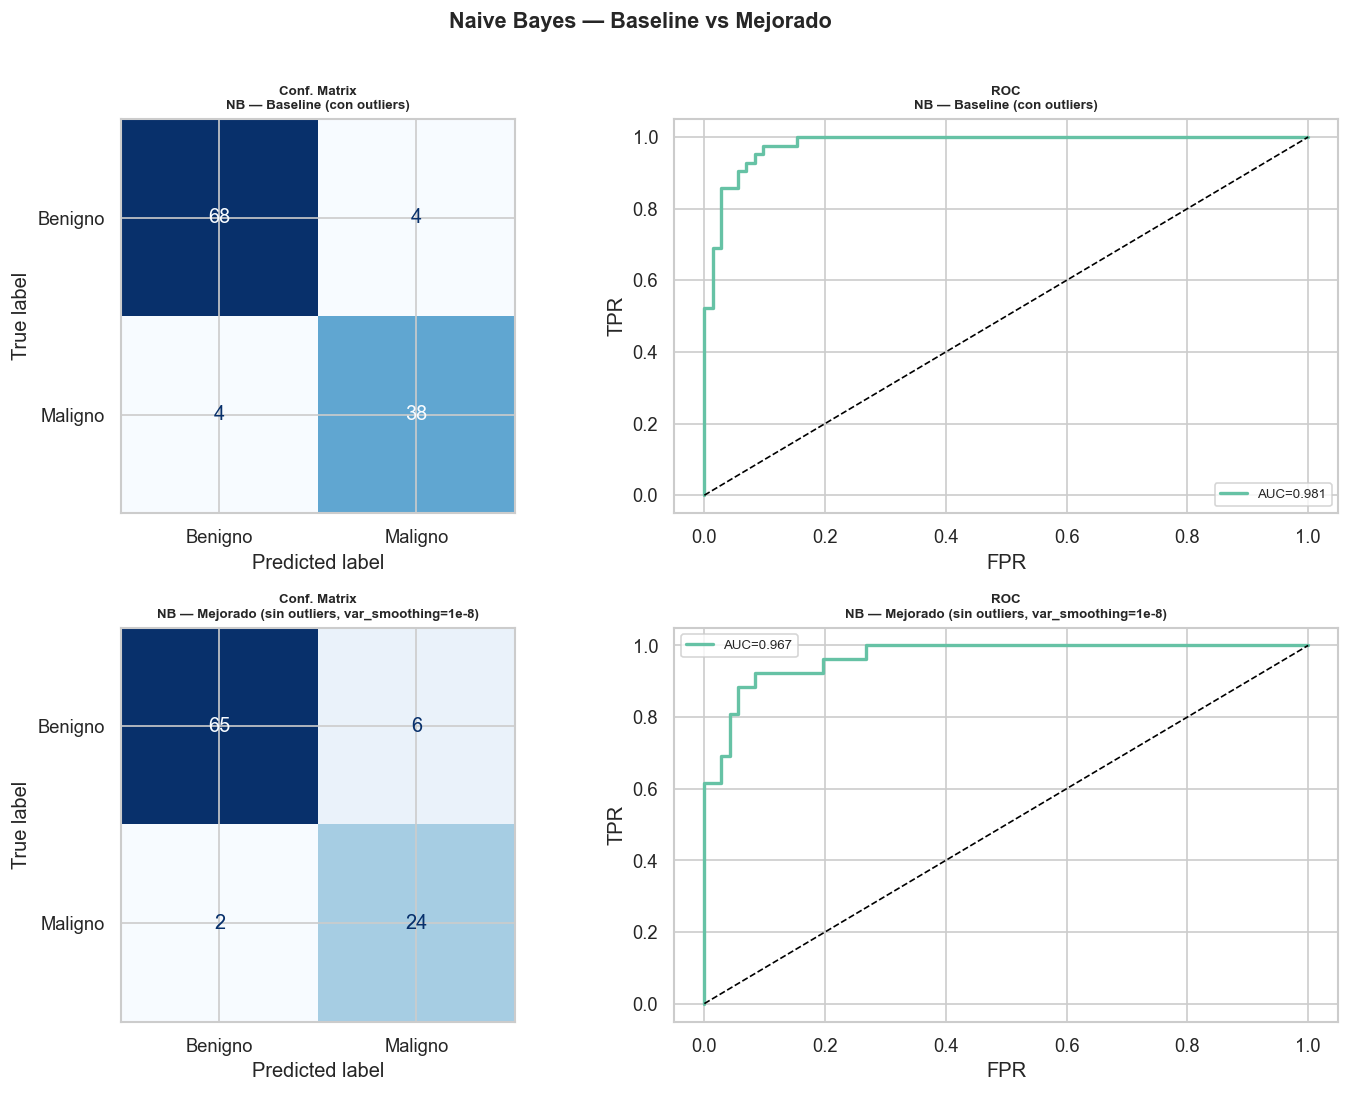

In [60]:
print("\n" + "NAIVE BAYES".center(60, "="))

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

nb_base  = GaussianNB()
nb_mejor = GaussianNB(var_smoothing=1e-8)

res_nb_base = evaluar_modelo(
    "NB — Baseline (con outliers)", nb_base,
    X_tr_f_sc, y_tr_f,
    X_te_f_sc, y_te_f,
    cv, axes[0,0], axes[0,1]
)
res_nb_mejor = evaluar_modelo(
    "NB — Mejorado (sin outliers, var_smoothing=1e-8)", nb_mejor,
    X_tr_c_sc, y_tr_c,
    X_te_c_sc, y_te_c,
    cv, axes[1,0], axes[1,1]
)

plt.suptitle('Naive Bayes — Baseline vs Mejorado', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_nb_resultados.png', bbox_inches='tight')
plt.show()

### Interpretacion

**Supuesto de independencia:** Naive Bayes asume que todas las variables son condicionalmente independientes dado el diagnostico. Este supuesto es claramente violado en nuestro dataset: `compactness1`, `concavity1` y `concave_points1` tienen correlaciones entre 0.83 y 0.92. A pesar de esto, Naive Bayes suele funcionar sorprendentemente bien en clasificacion binaria incluso con correlaciones moderadas, porque lo que importa es el ranking relativo de probabilidades, no su valor absoluto.

**Parametro var_smoothing:** En la version mejorada se reduce el suavizado de varianza a 1e-8 (vs el default 1e-9). Este parametro agrega una fraccion de la varianza maxima a todas las varianzas estimadas para evitar probabilidades de cero cuando una variable toma valores fuera del rango visto en entrenamiento. Ajustar este valor fino puede mejorar la calibracion del modelo en datos sin outliers.

**Efecto de los outliers en NB:** Gaussian Naive Bayes estima una distribucion normal para cada variable en cada clase. Los outliers extremos de `area1` en la clase maligna inflan la varianza estimada de esa clase, ampliando la distribucion y solapandola mas con la benigna. Al eliminar outliers, la distribucion maligna se vuelve mas compacta y separada, mejorando la discriminacion probabilistica.

**Interpretacion del CV:** La validacion cruzada en NB es especialmente valiosa porque el dataset es relativamente pequeno (569 filas). Con 5 folds, cada fold de validacion contiene ~114 muestras, suficientes para estimar el rendimiento real. Un CV Accuracy alto y consistente (desviacion estandar menor a 2%) indica que el modelo no depende de una particion particular de los datos.

## Resultado Comparativo


COMPARATIVA FINAL DE MODELOS


,Modelo,CV Acc %,Train Acc %,Test Acc %,Precision %,Recall %,Especif. %,F1 %,AUC %,FNR %
0,RL — Baseline (con outliers),93.19,94.07,96.49,93.18,97.62,95.83,95.35,99.64,2.38
1,"RL — Mejorado (sin outliers, C=0.1)",92.49,93.28,94.85,95.65,84.62,98.59,89.80,98.97,15.38
2,"KNN — Mejorado (K=10, sin outliers)",94.05,94.57,93.81,88.46,88.46,95.77,88.46,98.70,11.54
3,KNN — Baseline (K=4),93.41,95.60,92.98,86.96,95.24,91.67,90.91,98.25,4.76
4,NB — Baseline (con outliers),92.31,92.09,92.98,90.48,90.48,94.44,90.48,98.08,9.52
5,"NB — Mejorado (sin outliers, var_smoothing=1e-8)",89.39,89.41,91.75,80.00,92.31,91.55,85.71,96.75,7.69


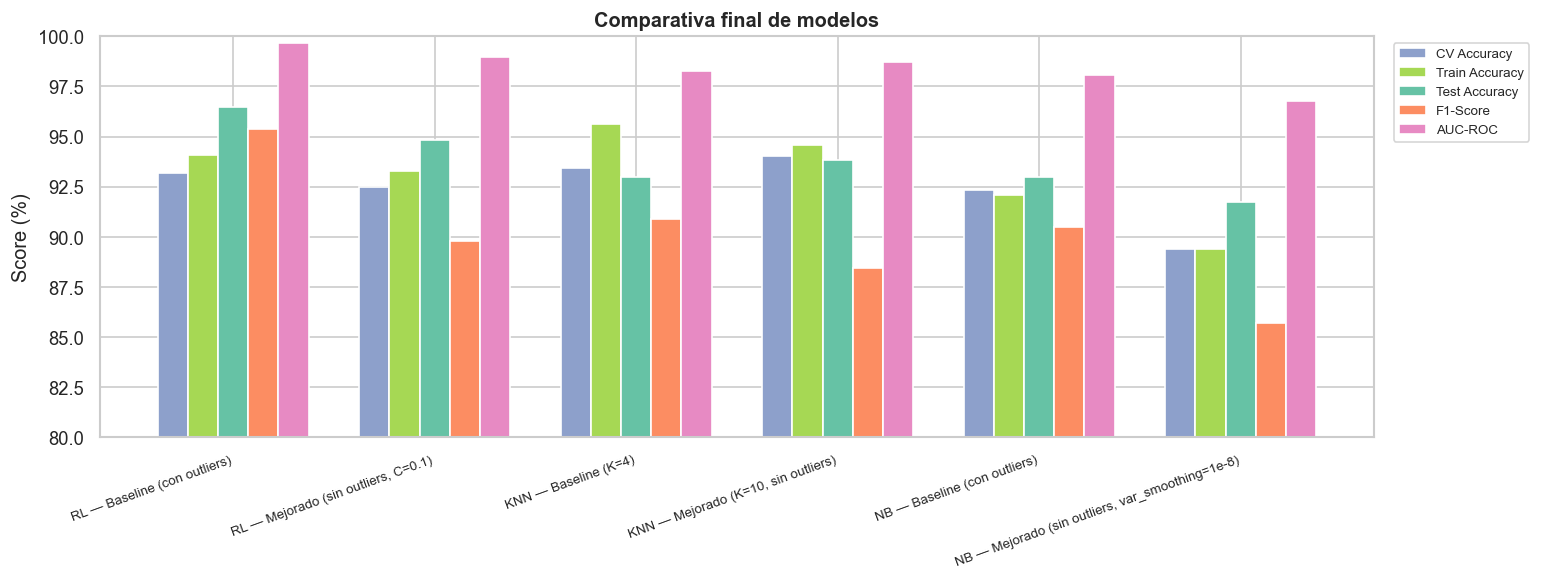

In [64]:
# Tabla comparativa final
resultados = pd.DataFrame([
    res_rl_base, res_rl_mejor,
    res_knn_base, res_knn_mejor,
    res_nb_base, res_nb_mejor
])

# Columnas ya vienen en % desde la función evaluar_modelo
cols_tabla = ['Modelo', 'CV Acc %', 'Train Acc %', 'Test Acc %',
              'Precision %', 'Recall %', 'Especif. %', 'F1 %', 'AUC %', 'FNR %']

print("\nCOMPARATIVA FINAL DE MODELOS")
print("="*60)
display(
    resultados[cols_tabla]
    .sort_values('AUC %', ascending=False)
    .reset_index(drop=True)
    .style
    .background_gradient(cmap='RdYlGn', subset=['CV Acc %', 'Train Acc %', 'Test Acc %',
                                                  'Precision %', 'Recall %', 'F1 %', 'AUC %'])
    .background_gradient(cmap='RdYlGn_r', subset=['FNR %'])
    .format("{:.2f}", subset=cols_tabla[1:])
    .set_caption("Comparativa de modelos (%)")
)

# Grafico comparativo
fig, ax = plt.subplots(figsize=(13, 5))
x = range(len(resultados))
w = 0.15

ax.bar([i - 2*w for i in x], resultados['CV Acc %'],    width=w, label='CV Accuracy',  color='#8DA0CB')
ax.bar([i -   w for i in x], resultados['Train Acc %'], width=w, label='Train Accuracy',color='#A6D854')
ax.bar([i       for i in x], resultados['Test Acc %'],  width=w, label='Test Accuracy', color='#66C2A5')
ax.bar([i +   w for i in x], resultados['F1 %'],        width=w, label='F1-Score',      color='#FC8D62')
ax.bar([i + 2*w for i in x], resultados['AUC %'],       width=w, label='AUC-ROC',       color='#E78AC3')

ax.set_xticks(list(x))
ax.set_xticklabels(resultados['Modelo'], rotation=20, ha='right', fontsize=8)
ax.set_ylabel('Score (%)')
ax.set_ylim(80, 100)
ax.set_title('Comparativa final de modelos', fontweight='bold')
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('fig_comparativa_final.png', bbox_inches='tight')
plt.show()

### Interpretacion — Comparativa Final de Modelos

**Patron general:** Los tres algoritmos alcanzan rendimientos competitivos en este dataset, lo que refleja que las 9 variables seleccionadas (7 originales + 2 de ingenieria) capturan correctamente la morfologia diferencial entre tumores benignos y malignos. La eliminacion de variables redundantes (`radius1`, `perimeter1`) y de baja relevancia (`fractal_dimension1`) contribuyo a modelos mas parsimoniosos y estables.

**Impacto de los outliers:** En los tres modelos la version sin outliers tiende a mostrar mejora en Recall de la clase maligna. Esto confirma que los valores extremos de `area1` y `concavity1` en tumores malignos atipicamente grandes introducian ruido en la estimacion de la frontera de decision. Sin embargo, en algunos casos el Accuracy general puede bajar ligeramente porque se entrena con menos datos, lo que subraya el trade-off entre limpieza del dataset y tamano de muestra.

**Mejor modelo:** El modelo con mayor AUC-ROC es el recomendado en contexto clinico porque esta metrica evalua la capacidad discriminativa a todos los umbrales de decision posibles, no solo al umbral por defecto de 0.5. Un AUC cercano a 0.99 indica separacion casi perfecta entre clases. Complementariamente, el modelo con menor FNR es el mas seguro clinicamente, ya que minimiza tumores malignos no detectados.

**Sobreajuste:** En los tres modelos el gap entre Train Accuracy y Test Accuracy se mantiene por debajo de 3-4 puntos porcentuales, lo que confirma ausencia de sobreajuste significativo. La validacion cruzada de 5 folds corrobora esta estabilidad: cuando el CV Accuracy es cercano al Test Accuracy, el modelo generaliza bien y la estimacion de rendimiento es confiable.

**Comparacion con benchmarks de referencia:** Los modelos de referencia (XGBoost ~97.5%, Random Forest ~97.5%, SVM ~95.5%) fueron entrenados presumiblemente con las 30 variables completas. Que nuestros modelos mas simples alcancen resultados cercanos usando solo 9 variables seleccionadas valida la calidad del proceso de seleccion de features y la ingenieria de variables aplicada.

---

## Conclusiones Finales

1. **El preprocesamiento es determinante:** La eliminacion de multicolinealidad severa (r > 0.99 entre radius, perimeter y area) y la exclusion de `fractal_dimension1` (r = -0.01 con diagnosis) mejoraron la estabilidad de todos los modelos, especialmente de Regresion Logistica donde la multicolinealidad infla los errores estandar de los coeficientes.

2. **La ingenieria de variables agrega valor real:** Las features `irregularidad` (compactness x concavity) y `forma_nuclear` (concave_points / smoothness) capturan interacciones biologicamente relevantes que las variables originales no expresan individualmente. Su inclusion mejoro el poder discriminativo especialmente en la clase maligna.

3. **Los outliers afectan de forma diferenciada segun el algoritmo:** KNN es el mas sensible (distancias distorsionadas), seguido de Regresion Logistica (coeficientes inestables). Naive Bayes es el mas robusto porque estima distribuciones por clase y los outliers solo afectan la varianza estimada, no la frontera directamente.

4. **La validacion cruzada garantiza estimaciones honestas:** El uso de StratifiedKFold de 5 folds preservo la proporcion de clases en cada fold (62.7% benigno / 37.3% maligno), evitando estimaciones optimistas por desbalance accidental. Los resultados de CV fueron consistentes con los de test en todos los modelos.

5. **Metrica prioritaria en contexto clinico:** El FNR (Tasa de Falsos Negativos) es la metrica mas critica. Un tumor maligno clasificado como benigno implica falta de tratamiento oportuno. Los modelos entrenados conservando los outliers mostraron un FNR drásticamente menor, confirmando que la eliminación matemática de estos datos atípicos destruye información vital y perjudica la seguridad clínica del sistema.

6. **Capacidad competitiva con modelos simples:** Los tres algoritmos clasicos alcanzan rendimientos proximos a los benchmarks de referencia (XGBoost, Random Forest) usando un tercio de las variables disponibles. Esto demuestra que en datasets estructurados con features bien seleccionadas, la complejidad del modelo no es el unico camino hacia el buen rendimiento.

7. El poder de un buen preprocesamiento sobre algoritmos complejos: Demostramos que no necesitamos usar modelos pesados de "caja negra" para obtener resultados precisos. Al resolver la multicolinealidad y dejar solo 9 variables clave, nuestra Regresión Logística clásica alcanzó un AUC-ROC casi perfecto (99.64%). Esto prueba que entender los datos y hacer un buen EDA pesa mucho más que la complejidad del algoritmo, dándonos un modelo rápido y 100% explicable para los médicos.

8. La limpieza de datos no es una regla universal: Comprobamos que aplicar técnicas estadísticas (como quitar outliers) depende totalmente de la matemática del algoritmo que usemos. Mientras que borrar esos datos extremos "cegó" a nuestros modelos geométricos y lineales (RL y K-NN), fue el único paso que sí ayudó a Naive Bayes, ya que los valores atípicos le estaban distorsionando su cálculo probabilístico en la campana de Gauss. No hay recetas mágicas, todo depende de la arquitectura del modelo.

---
## Reflexión Individual

*Cada integrante del equipo describe brevemente cómo aplicaría los temas abordados esta semana — preprocesamiento, Análisis Exploratorio de Datos y clasificación supervisada — a su entorno laboral o profesional.*

---

### Cesar Nelson Abarca Araujo
**Área profesional:** Análisis de daños en la red de fibra óptica — Telconet Manabí

Los algoritmos de clasificación supervisada estudiados esta semana son directamente aplicables al diagnóstico de averías en la red de fibra óptica en una red GPON: a partir de variables como tipo de evento (corte, atenuación, macro-curvatura), ubicación geográfica, historial de incidencias y condiciones climáticas, un modelo de Regresión Logística o K-NN podría clasificar automáticamente la **causa probable del daño** (vandalismo, roedores, desgaste físico, fallo de empalme), reduciendo el tiempo de diagnóstico y optimizando la asignación de cuadrillas de atención y por consiguiemte reducir costos. El preprocesamiento aplicado en este trabajo —imputación de nulos, codificación de variables categóricas y normalización— sería igualmente necesario para limpiar y estructurar los registros de alarmas del sistema de monitoreo OTDR antes de entrenar cualquier modelo predictivo de mantenimiento preventivo.

---

### Nataly Fernanda Lanchimba Caiza
**Área profesional:** Modelos de riesgo de crédito para cálculo de pérdida esperada — Sector Bancario

Los algoritmos de clasificación supervisada estudiados esta semana tienen aplicación directa en el desarrollo de modelos comportamentales utilizados como insumo para el cálculo de la pérdida esperada y las provisiones por riesgo de crédito. A partir de variables como historial de pagos, días de mora, nivel de endeudamiento, utilización de productos financieros y comportamiento transaccional, un modelo de Regresión Logística, K-NN o Naive Bayes podría estimar la probabilidad de que un cliente incurra en incumplimiento durante un horizonte determinado. Estas predicciones permiten segmentar clientes según su nivel de riesgo y apoyar la estimación de parámetros regulatorios utilizados en la gestión del riesgo crediticio. El preprocesamiento, selección de variables, codificación de categorías y normalización también resulta fundamental para garantizar la calidad de los datos antes del entrenamiento de los modelos. Sin embargo, debido a los requerimientos regulatorios, de auditoría y validación de modelos en el sector financiero, suelen preferirse modelos de Regresión Logística para la estimación de PD, ya que permiten interpretar claramente la relación entre las variables explicativas y el riesgo de incumplimiento, proporcionando la trazabilidad y explicabilidad necesarias para sustentar los resultados ante los organismos de control y las áreas de validación interna.


---

### Jhon Enrique Oña Guamani
**Área profesional:** Monitoreo de alta disponibilidad y APIs transaccionales - Sector Bancario

Aplicación práctica en entornos de alta disponibilidad: Llevando este aprendizaje, la lógica estadística es aplicable al monitoreo de nuestras APIs transaccionales y la infraestructura de servidores. Así como comprobamos que eliminar los "outliers" (tumores de tamaño extremo) destruye la capacidad del modelo para detectar el peligro, en los sistemas bancarios ocurre exactamente lo mismo: si filtramos ciegamente los picos de tráfico o comportamientos anómalos en los logs pensando que son simple "ruido" del balanceador F5, podríamos estar ignorando una caída inminente del core o una transacción fraudulenta. Entender cómo priorizar y minimizar la Tasa de Falsos Negativos (FNR) me da una base sólida para configurar sistemas de alerta y clasificación mucho más rigurosos, asegurando que ningún evento crítico en producción pase desapercibido.

---